# Inter-Rater Label Comparison (Quality Control)

This notebook assesses labeling consistency by comparing a ground truth (GT) labeler against other labelers.

## Metrics Computed

### 1. Image-Level Detection
Binary classification: Did the labeler detect ANY irrigation in the image?
- **TP**: Both GT and comparison labeled irrigation
- **FP**: Only comparison labeled (false alarm)
- **FN**: Only GT labeled (missed detection)  
- **TN**: Neither labeled
- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN)

### 2. Area Overlap
Continuous metric: How much do the labeled polygon areas agree?
- For each image, union all polygons per labeler
- **Precision** = intersection_area / comp_area (% of marked area that was correct)
- **Recall** = intersection_area / gt_area (% of GT area that was found)
- **IoU** = intersection_area / union_area
- Overall metrics sum areas across all images before computing ratios

## Output Files
All outputs are saved to the specified `output_dir`:
- `{op}_confusion_matrix.png` - Image detection confusion matrix
- `{op}_detection_metrics.png` - Detection metrics bar chart
- `{op}_area_metrics.png` - Area overlap bar chart
- `{op}_area_histograms.png` - Per-image metric distributions
- `{site_id}_{date}.png` - Side-by-side polygon comparison plots
- `image_detection_metrics.csv` - Summary table with weighted averages
- `area_overlap_metrics.csv` - Summary table with weighted averages

In [13]:
# Import the comparison class
import sys
sys.path.insert(0, '..')
from src.labels.label_comparison import LabelComparison

## Run Comparison: AB (Ground Truth) vs PS

In [14]:
# Define paths
irrigation_table_path = '../data/labels/labeled_surveys/random_sample/latest_irrigation_table.csv'
polygons_path = '../data/labels/labeled_surveys/random_sample/latest_polygons.geojson'
image_boundaries_path = '../data/labels/labeled_surveys/random_sample/latest_irrigation_data.geojson'

# Create comparison object comparing AB (ground truth) to all other labelers
# Figures will be automatically saved to the output directory
comparison = LabelComparison(
    irrigation_table_path=irrigation_table_path,
    polygons_path=polygons_path,
    image_boundaries_path=image_boundaries_path,
    gt_operator='PS',
    comparison_operators=['DSB', 'JL', 'KL', 'MV'], # , 'PS'],  # All other labelers
    min_certainty=3,  # Only include polygons with certainty above threshold
    date_tolerance_days=1,
    output_dir='../outputs/ps_comparisons_cert_3'  # Save all figures here
)

Figures will be saved to: ../outputs/ps_comparisons_cert_3
Loading data for PS vs ['DSB', 'JL', 'KL', 'MV']...
  Loaded 2780 image labels, 3576 polygons
  PS: 204 images, 89 polygons
  DSB: 588 images, 626 polygons
  JL: 582 images, 1310 polygons
  KL: 681 images, 961 polygons
  MV: 623 images, 465 polygons
  Filtering by certainty >= 3...
Matching images (±1 day tolerance)...
  PS vs DSB: 86 matched images
  PS vs JL: 100 matched images
  PS vs KL: 47 matched images
  PS vs MV: 88 matched images


## Access and Analyze Results

## Generate Detection Metrics Plots

Generate plots on demand for any comparison operator.


Generating detection plots for DSB...
Saved: ../outputs/ps_comparisons_cert_3/DSB_confusion_matrix.png


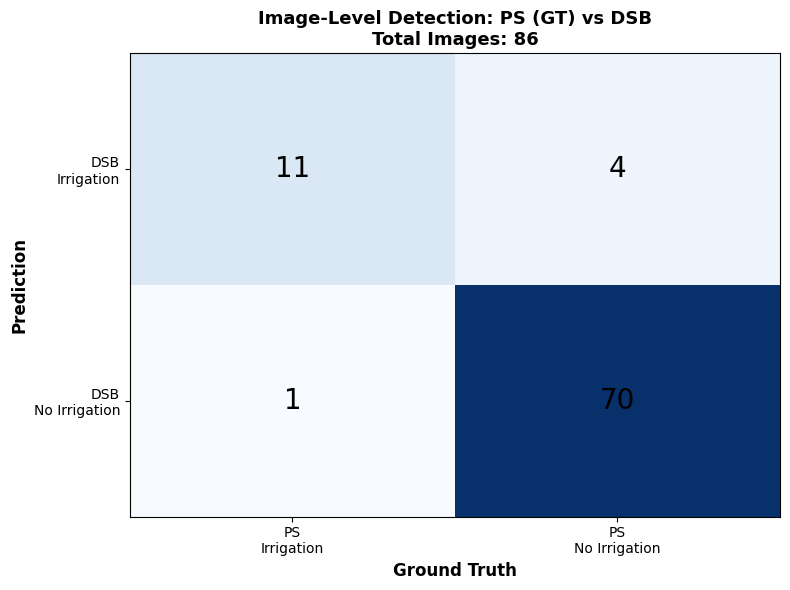

Saved: ../outputs/ps_comparisons_cert_3/DSB_detection_metrics.png


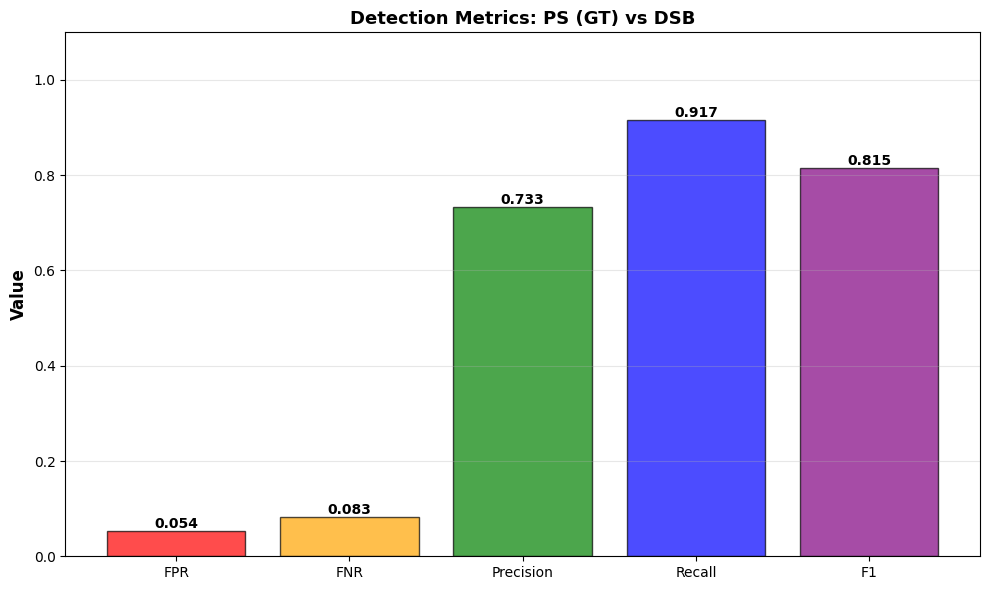


Generating detection plots for JL...
Saved: ../outputs/ps_comparisons_cert_3/JL_confusion_matrix.png


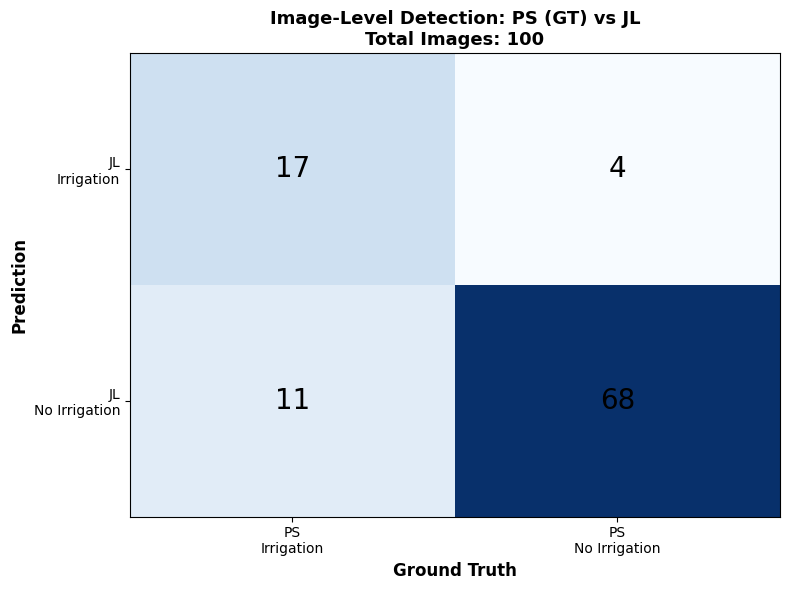

Saved: ../outputs/ps_comparisons_cert_3/JL_detection_metrics.png


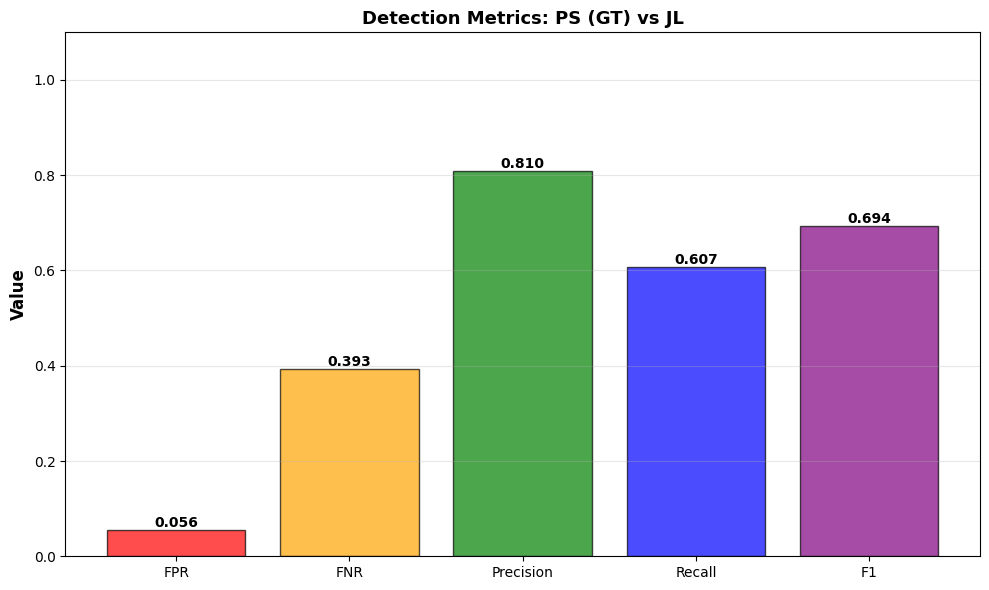


Generating detection plots for KL...
Saved: ../outputs/ps_comparisons_cert_3/KL_confusion_matrix.png


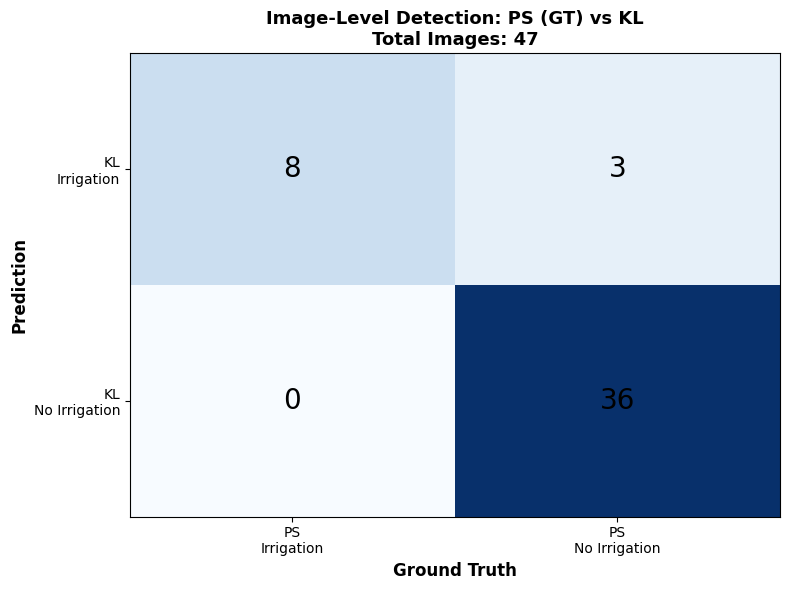

Saved: ../outputs/ps_comparisons_cert_3/KL_detection_metrics.png


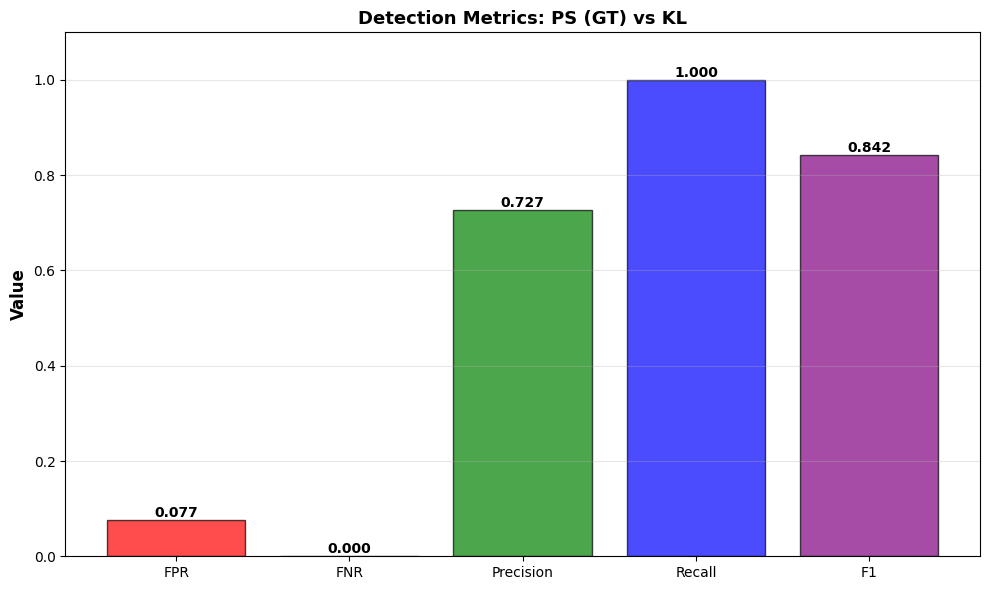


Generating detection plots for MV...
Saved: ../outputs/ps_comparisons_cert_3/MV_confusion_matrix.png


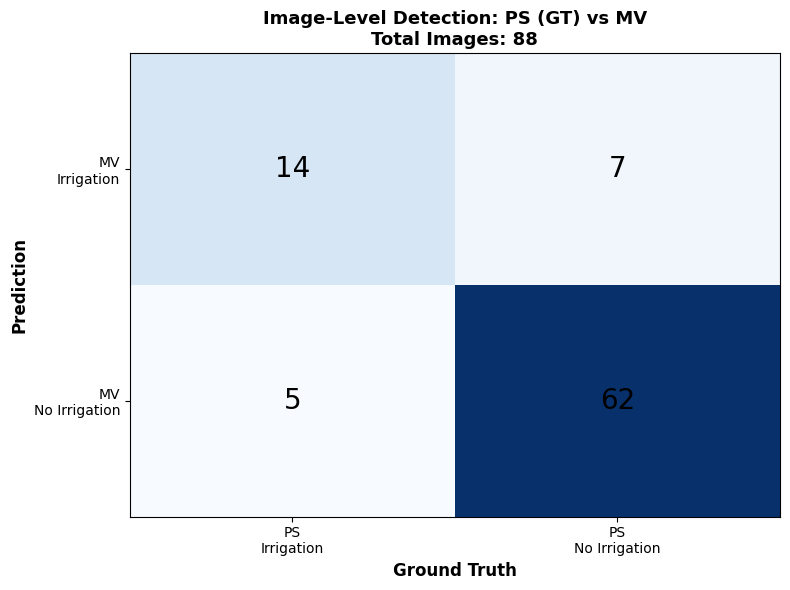

Saved: ../outputs/ps_comparisons_cert_3/MV_detection_metrics.png


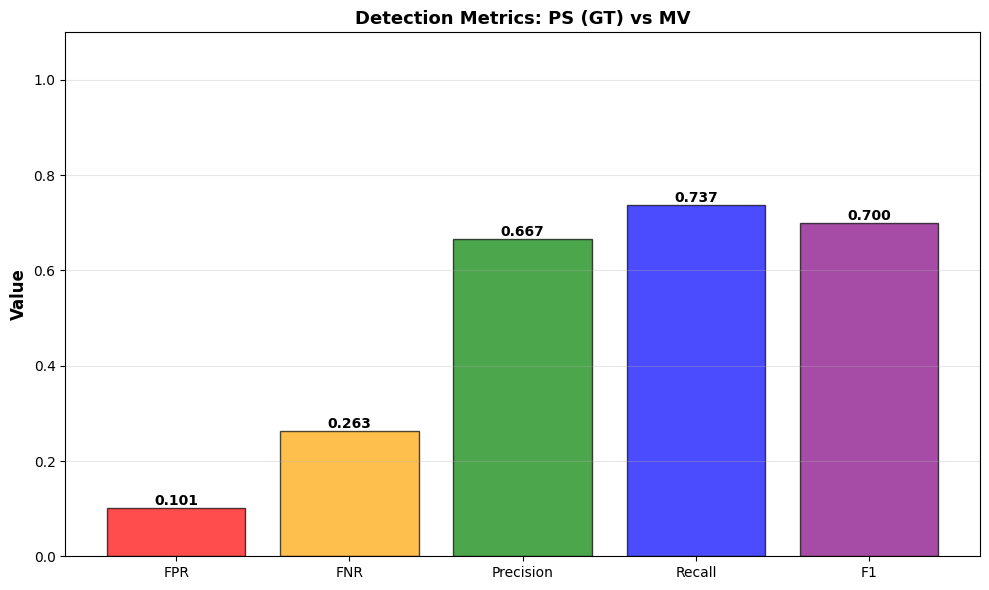

In [15]:
# Generate confusion matrices and detection metrics for all comparison operators
for op in comparison.comparison_operators:
    print(f"\nGenerating detection plots for {op}...")
    comparison.plot_confusion_matrix(op)
    comparison.plot_detection_metrics_bar(op)

## Generate Area Overlap Plots

View polygon-level area overlap metrics and histograms.


Generating area plots for DSB...
Saved: ../outputs/ps_comparisons_cert_3/DSB_area_metrics.png


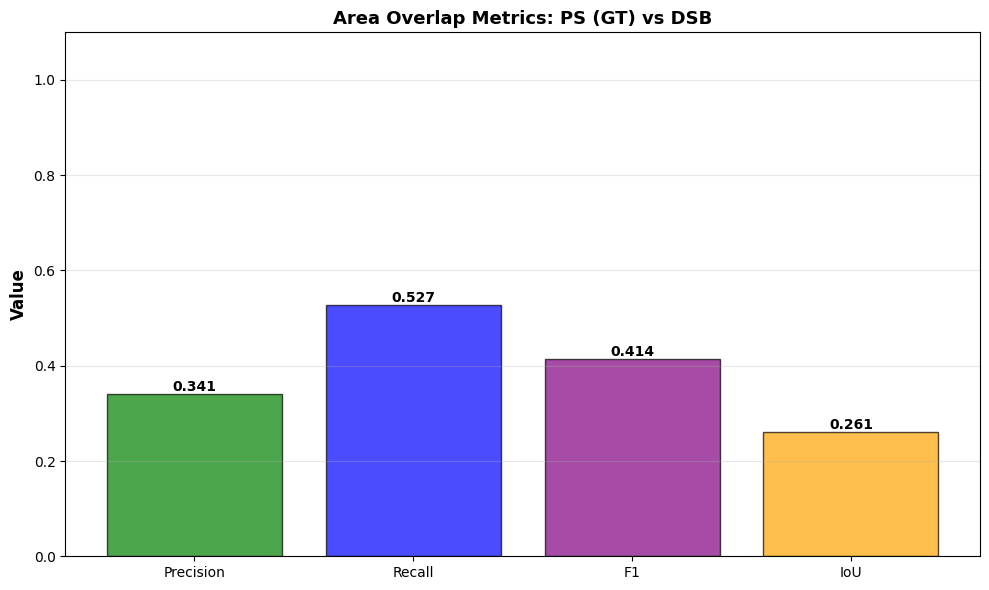

Saved: ../outputs/ps_comparisons_cert_3/DSB_area_histograms.png


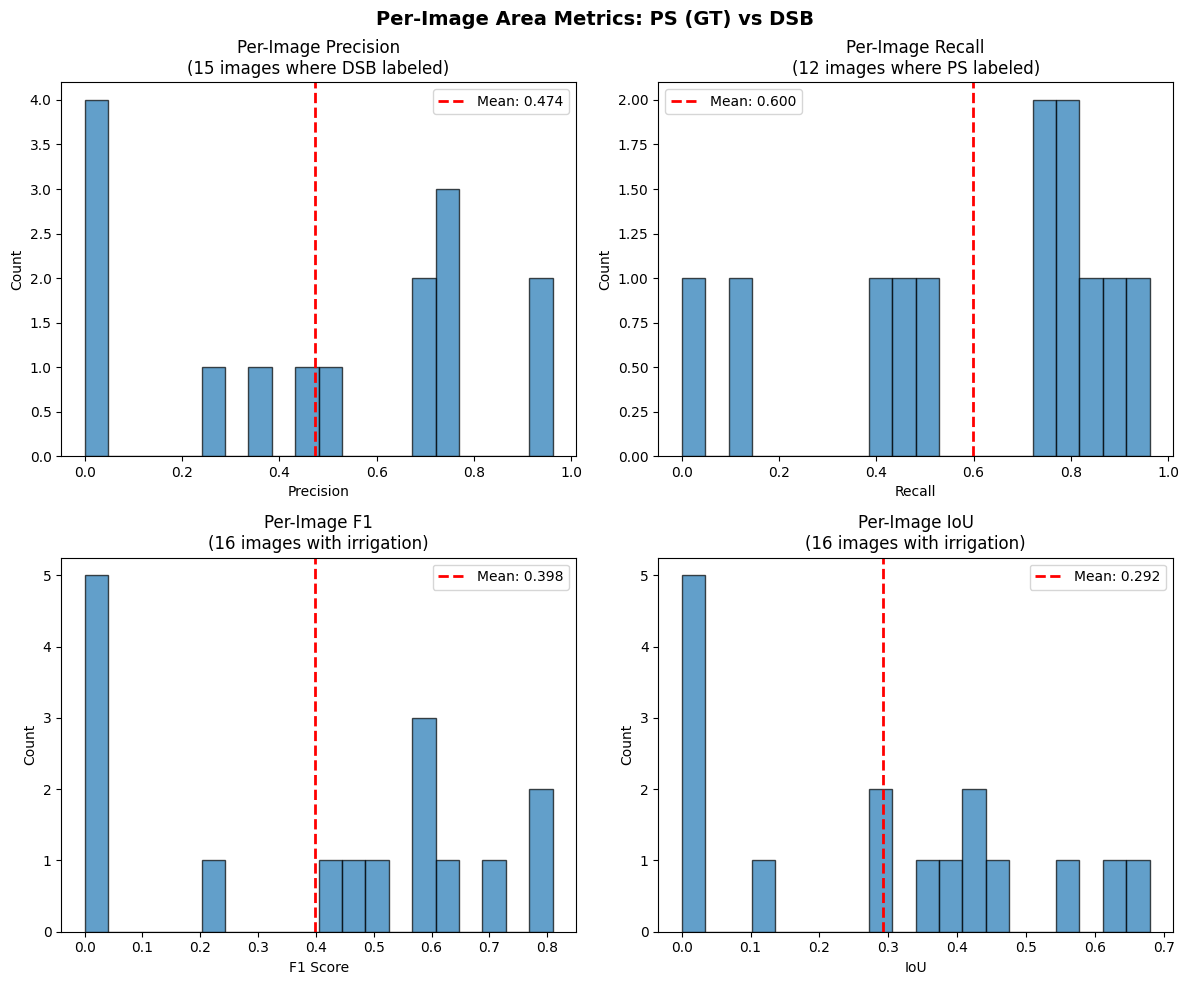


Generating area plots for JL...
Saved: ../outputs/ps_comparisons_cert_3/JL_area_metrics.png


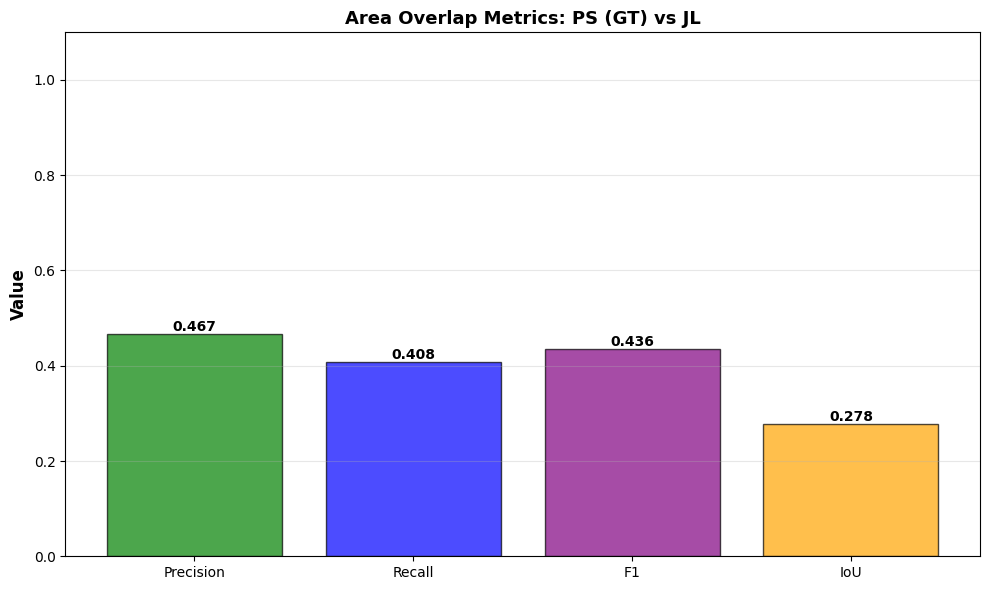

Saved: ../outputs/ps_comparisons_cert_3/JL_area_histograms.png


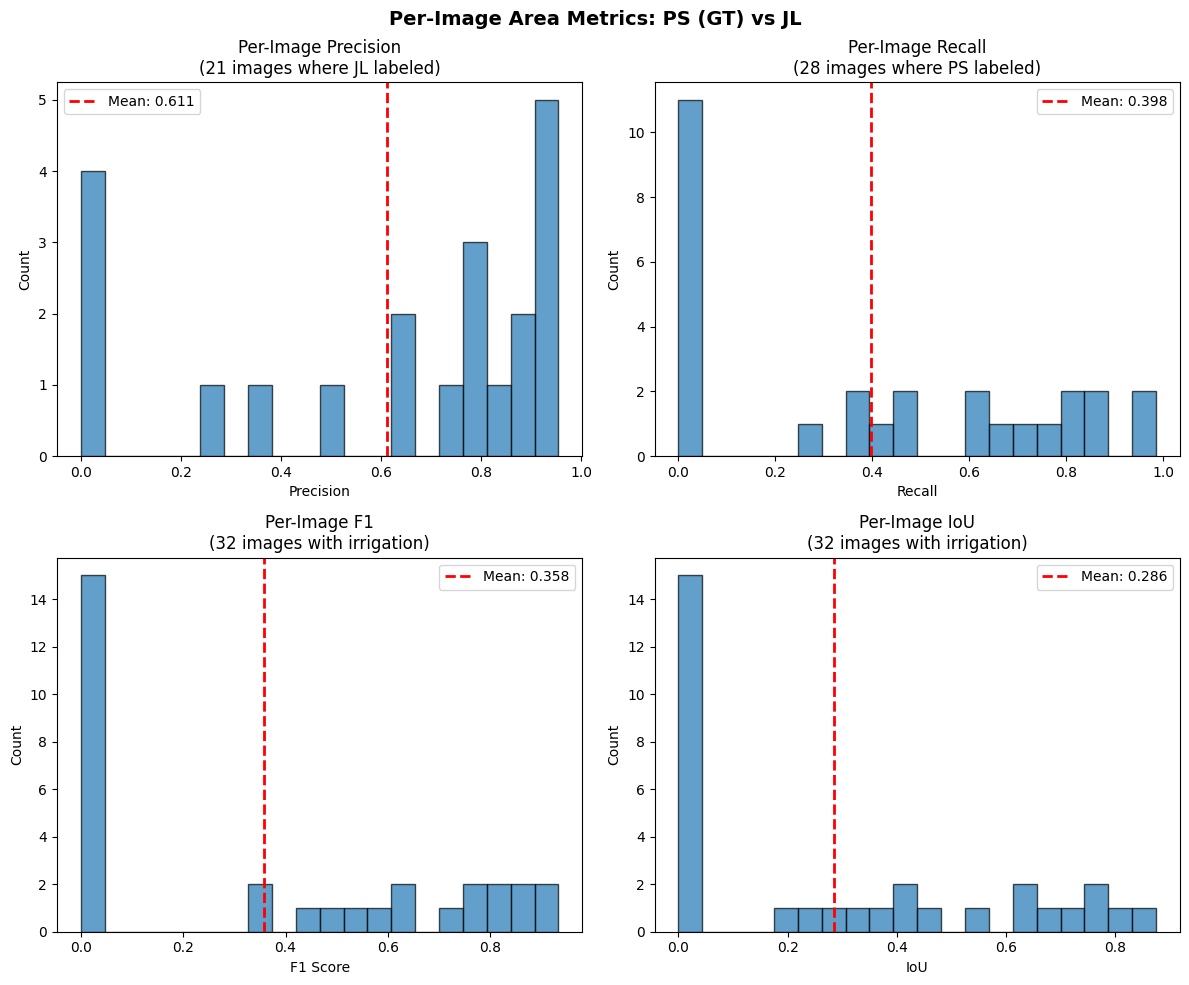


Generating area plots for KL...
Saved: ../outputs/ps_comparisons_cert_3/KL_area_metrics.png


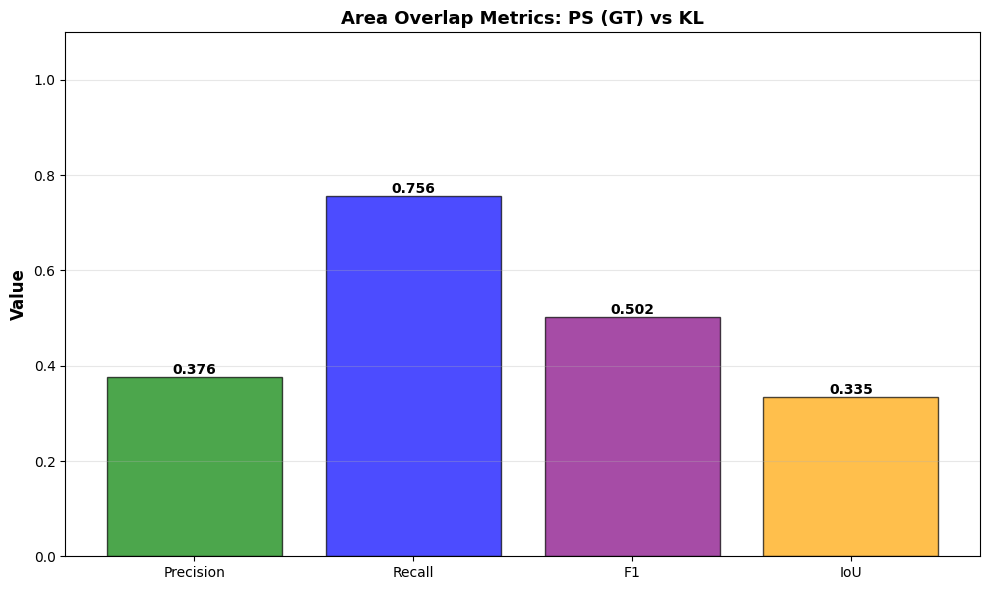

Saved: ../outputs/ps_comparisons_cert_3/KL_area_histograms.png


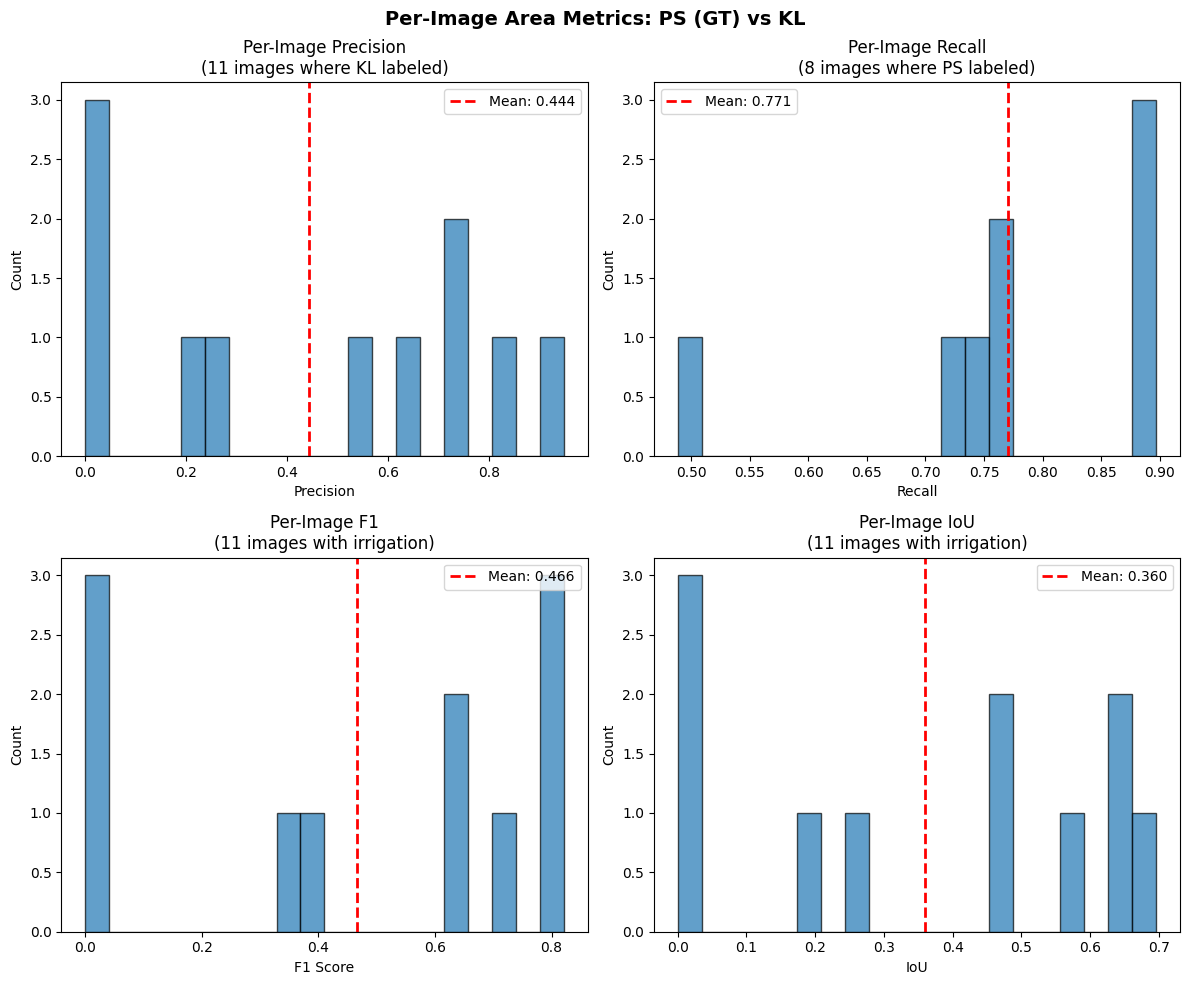


Generating area plots for MV...
Saved: ../outputs/ps_comparisons_cert_3/MV_area_metrics.png


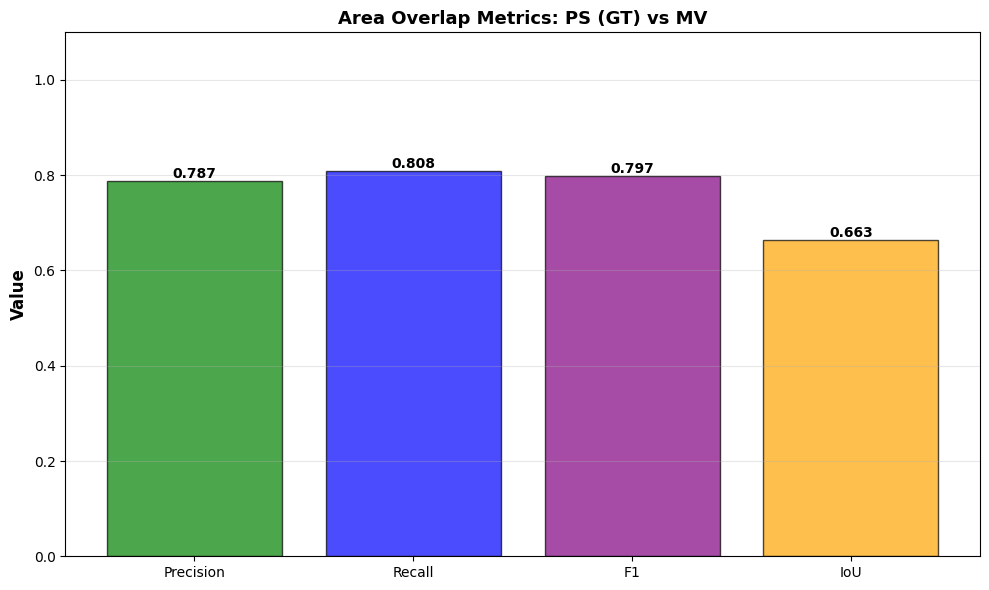

Saved: ../outputs/ps_comparisons_cert_3/MV_area_histograms.png


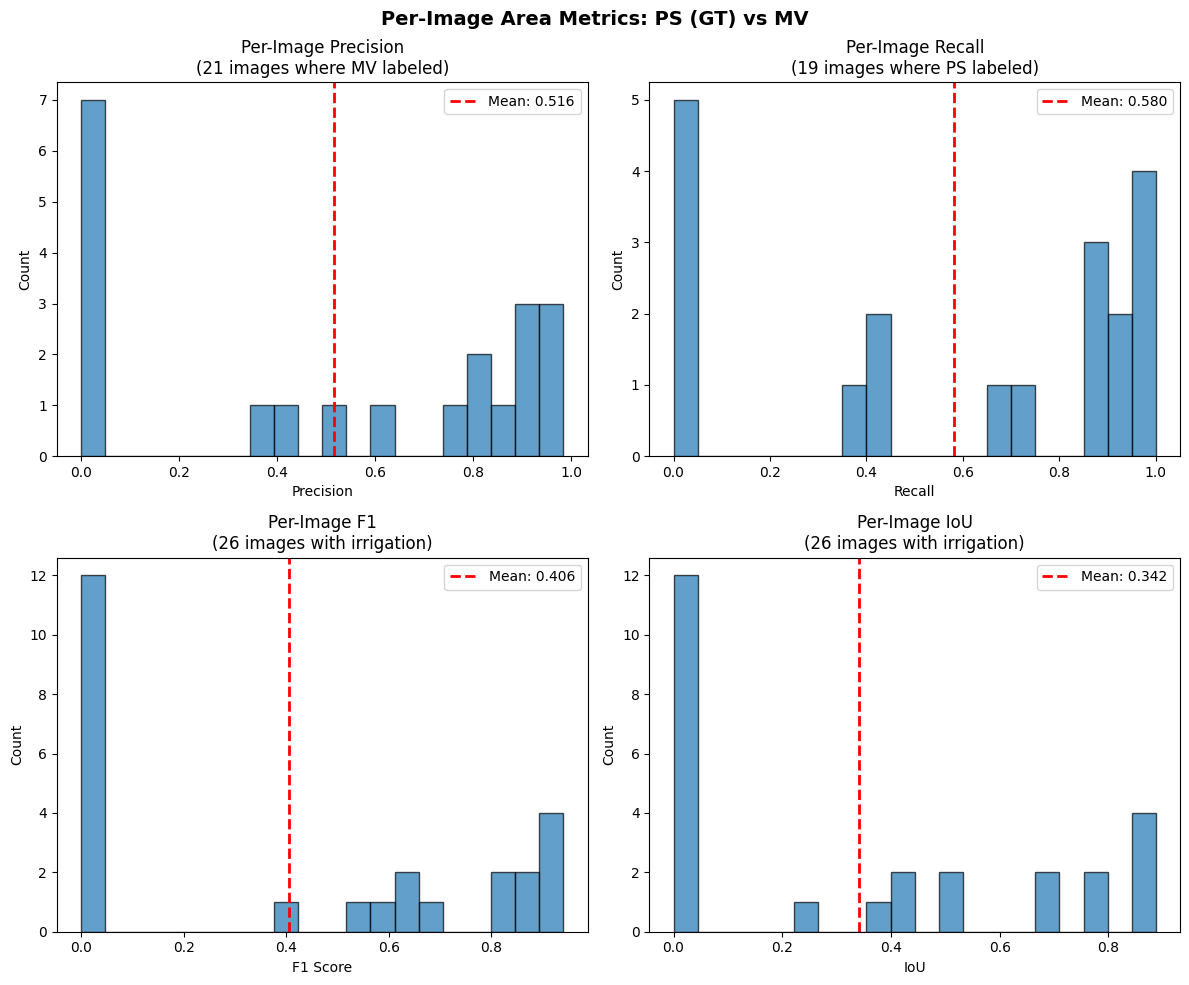

In [16]:
# Generate area overlap bar charts and histograms for all comparison operators
for op in comparison.comparison_operators:
    print(f"\nGenerating area plots for {op}...")
    comparison.plot_area_metrics_bar(op)  # New: bar chart of overall area metrics
    comparison.plot_area_histograms(op)   # Histograms of per-image area data

# # Access raw data for a specific operator if needed
# print("\nExample: Area data for PS")
# area_data = comparison.compute_area_metrics('PS')
# print(area_data[['site_id', 'n_gt', 'n_comp', 'gt_area', 'comp_area', 'intersection_area', 'union_area']].head())

# # Get overall metrics
# print("\nOverall area metrics for PS:")
# overall = comparison.compute_overall_area_metrics('PS')
# print(f"  Precision: {overall['precision']:.3f}")
# print(f"  Recall: {overall['recall']:.3f}")
# print(f"  IoU: {overall['iou']:.3f}")

## Plot Image Comparisons

Plot individual images or all matched images.

In [17]:
# # Plot a specific image
# matches = comparison.get_matches('PS')
# if len(matches) > 0:
#     first_match = matches.iloc[0]
#     comparison.plot_image_comparison(first_match['site_id'], first_match['gt_date'])


Plotting images with polygons...
Images will be saved to: ../outputs/ps_comparisons_cert_3
Plotting 52 images with polygons...


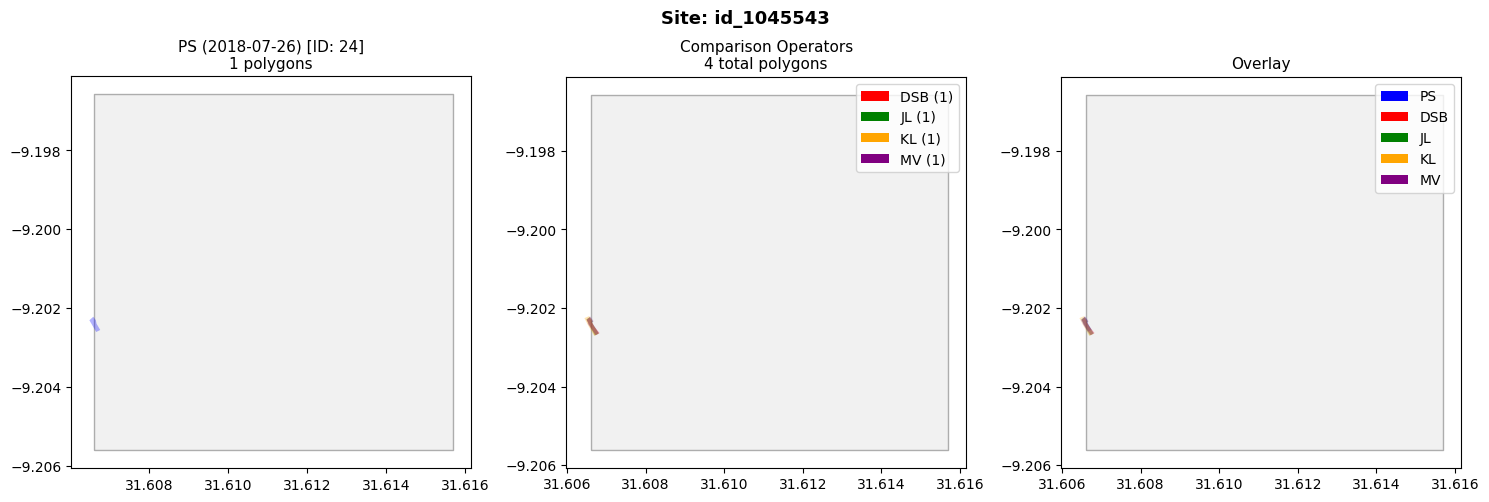

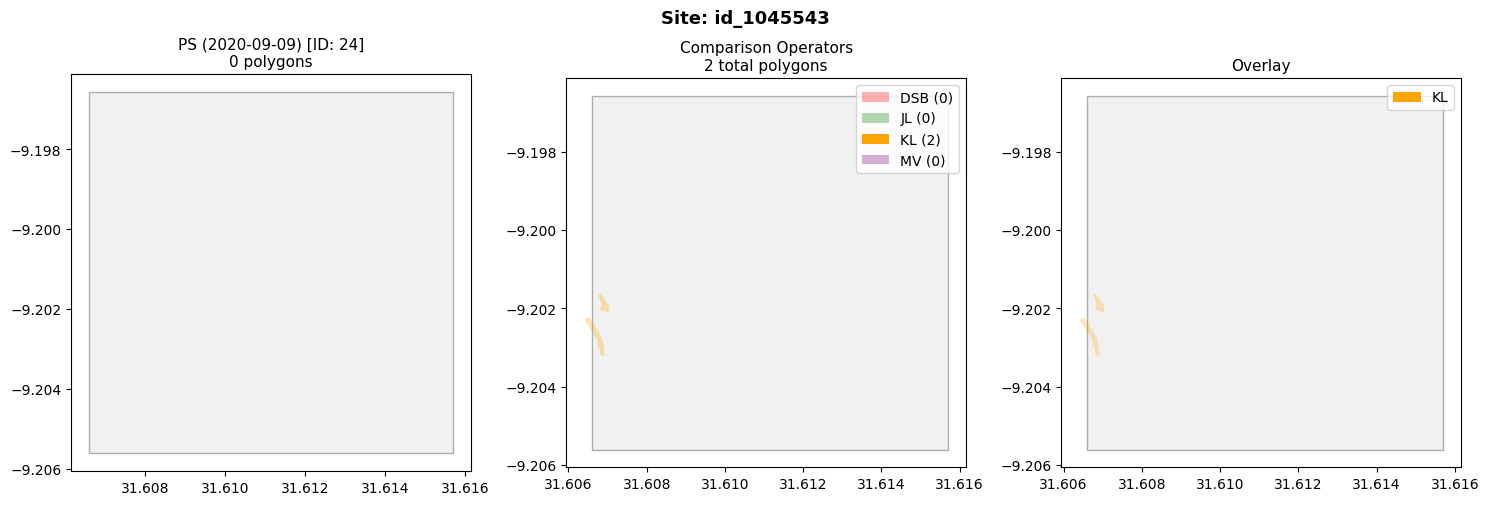

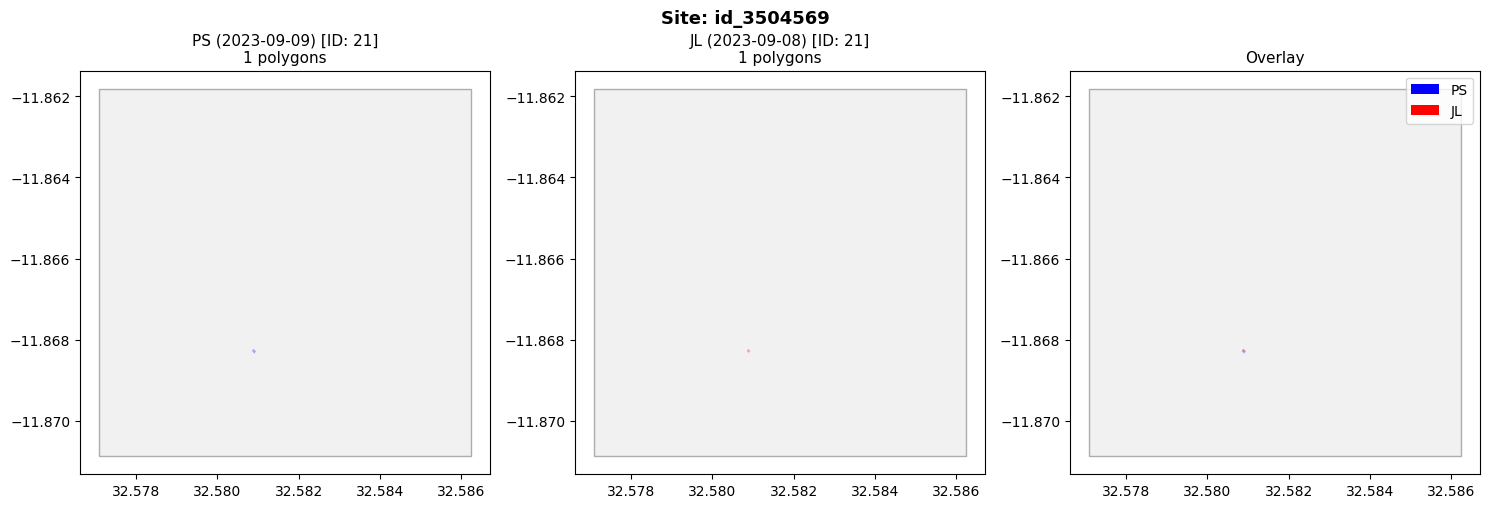

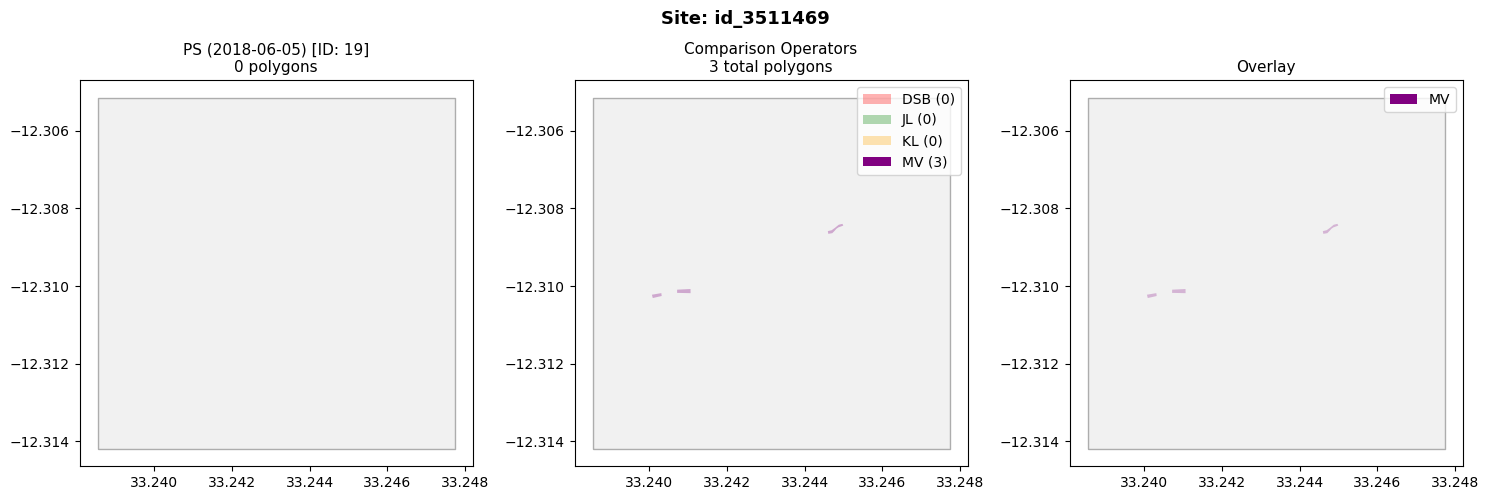

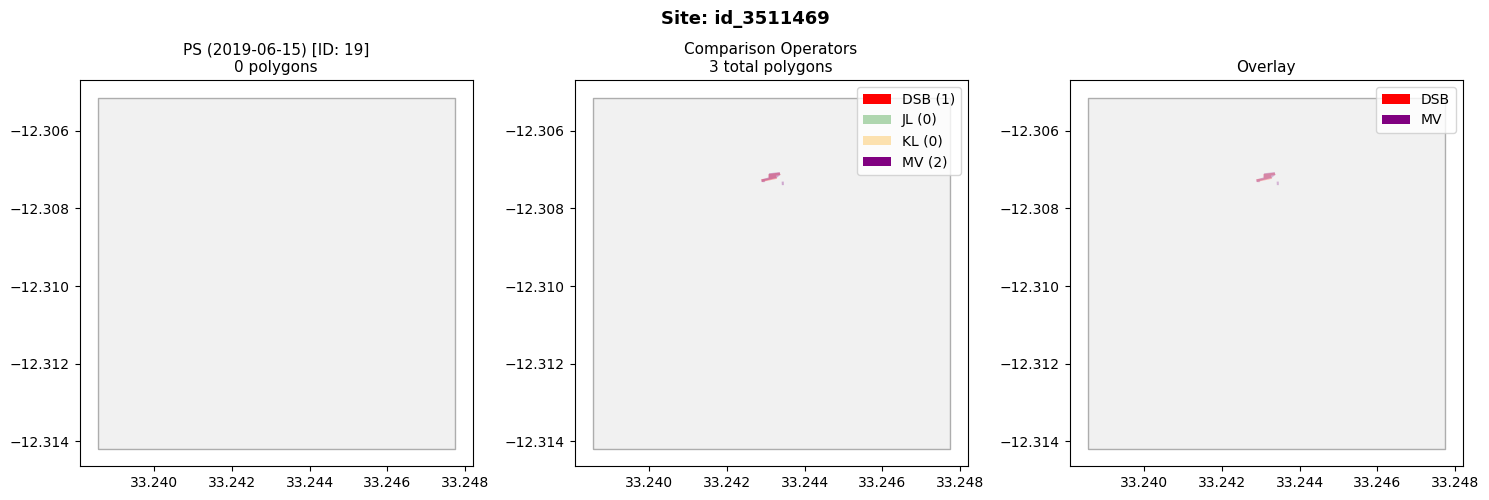

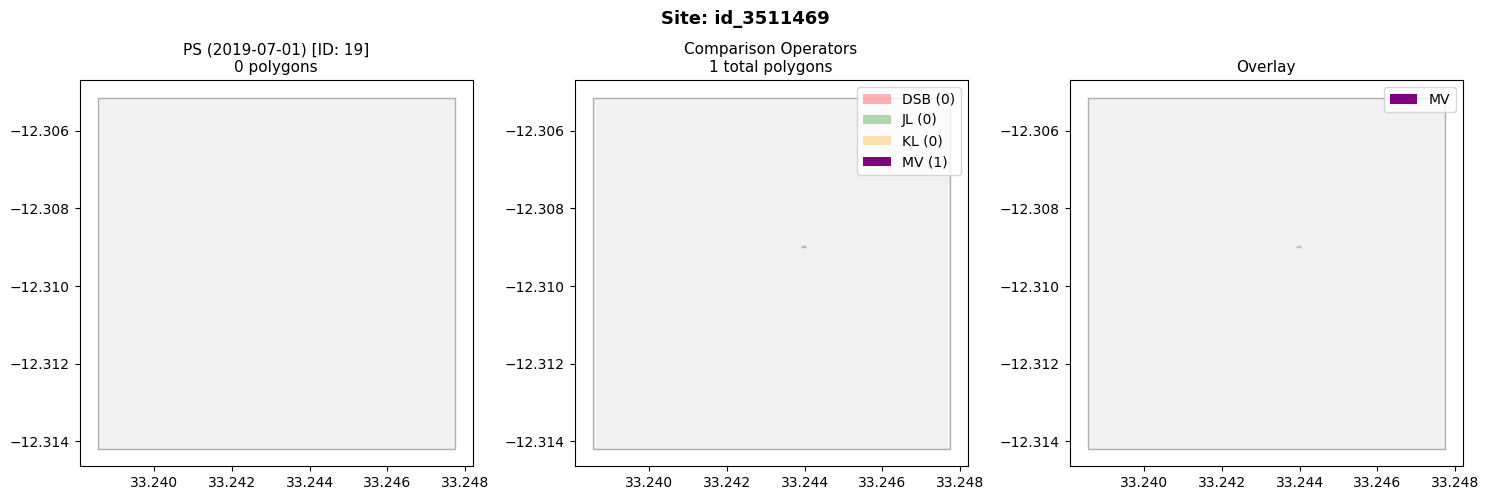

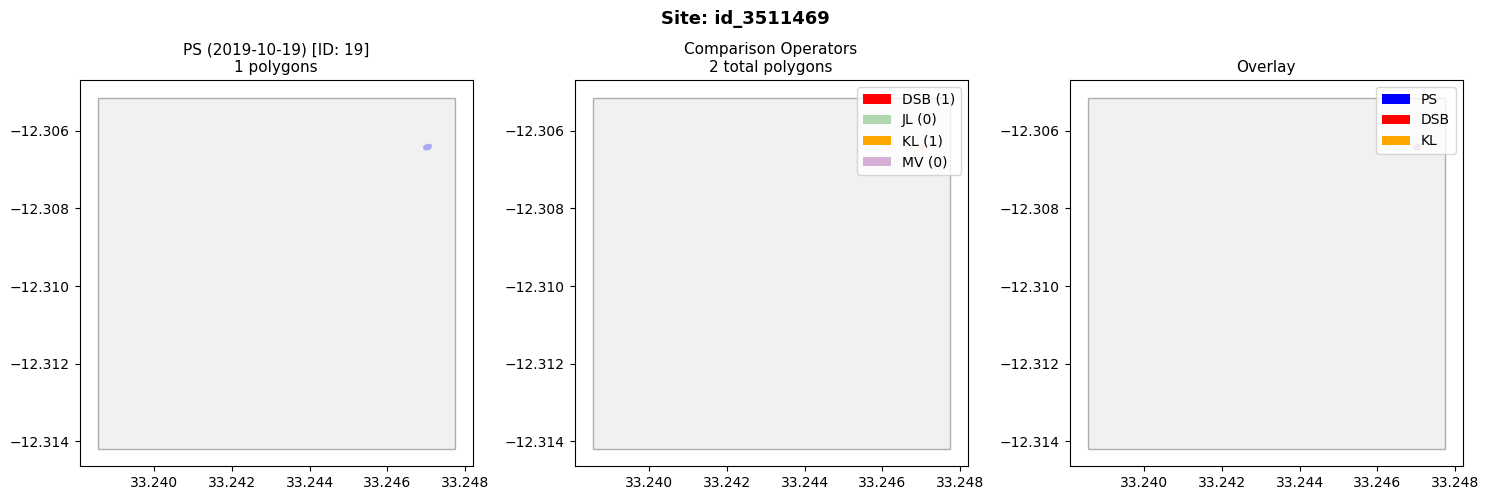

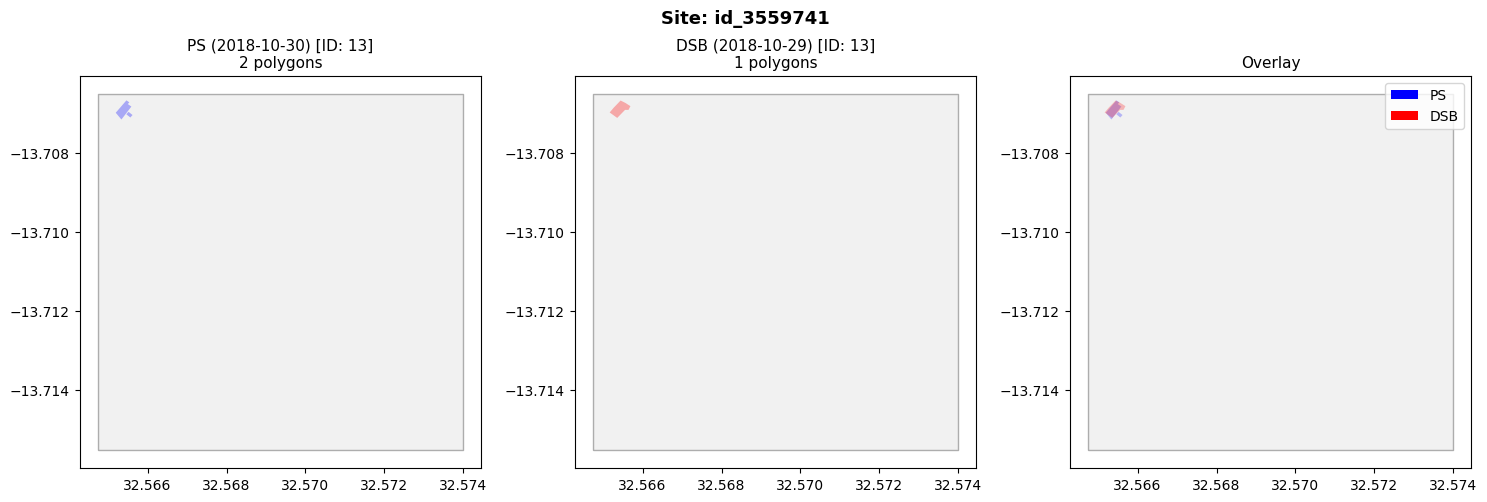

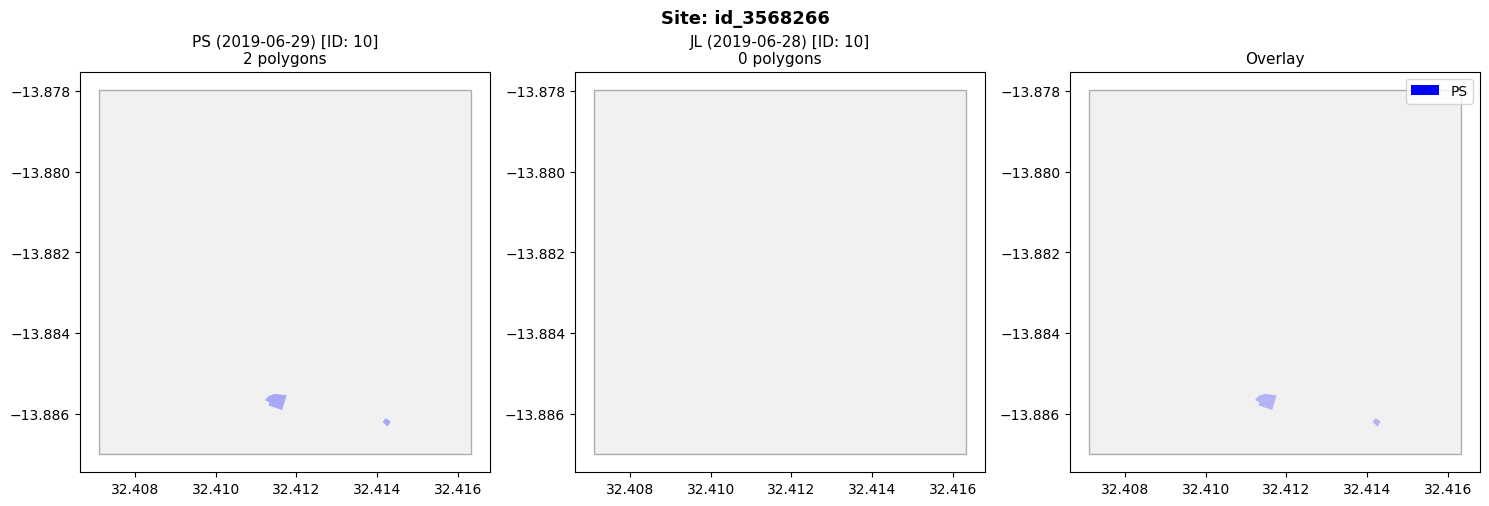

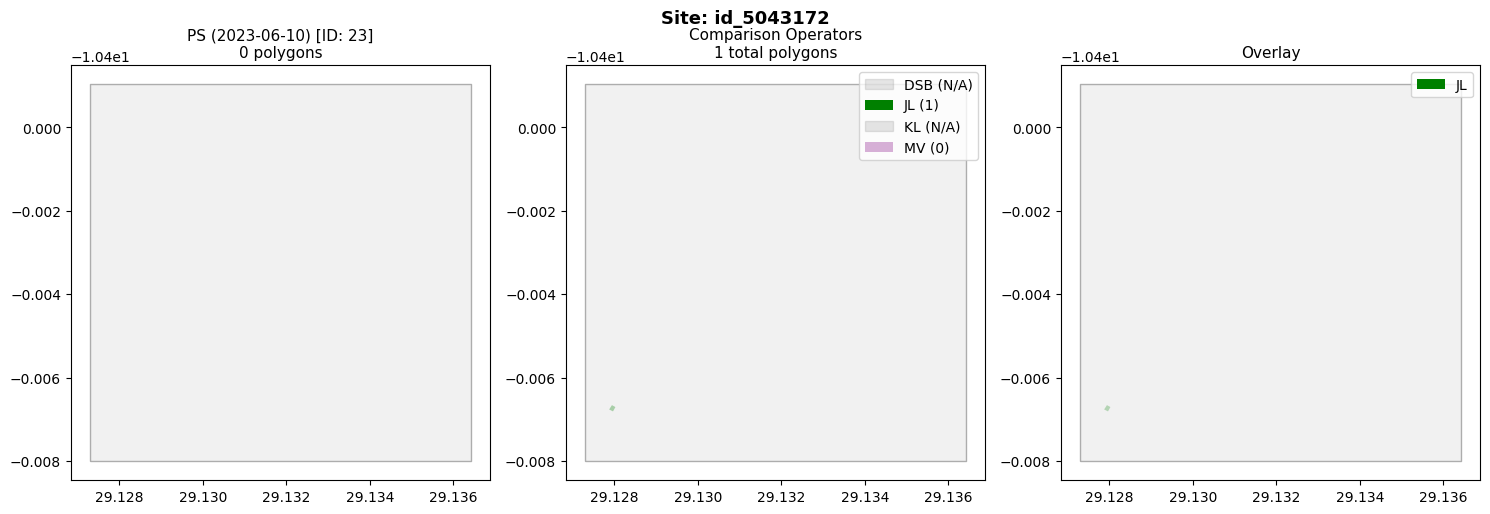

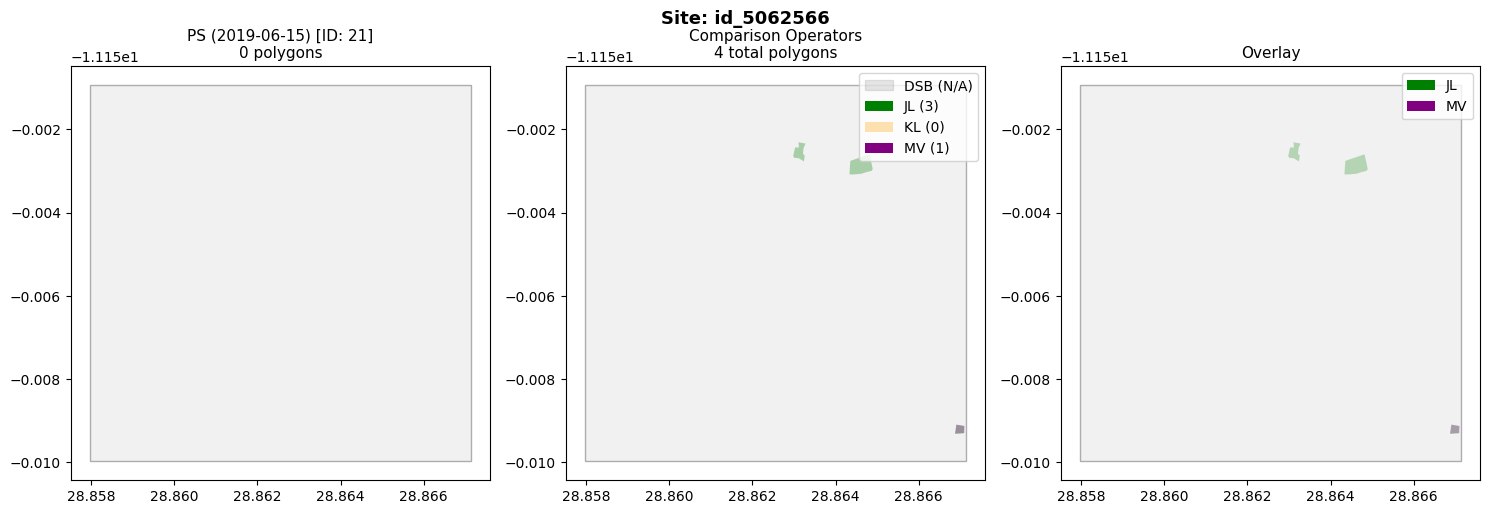

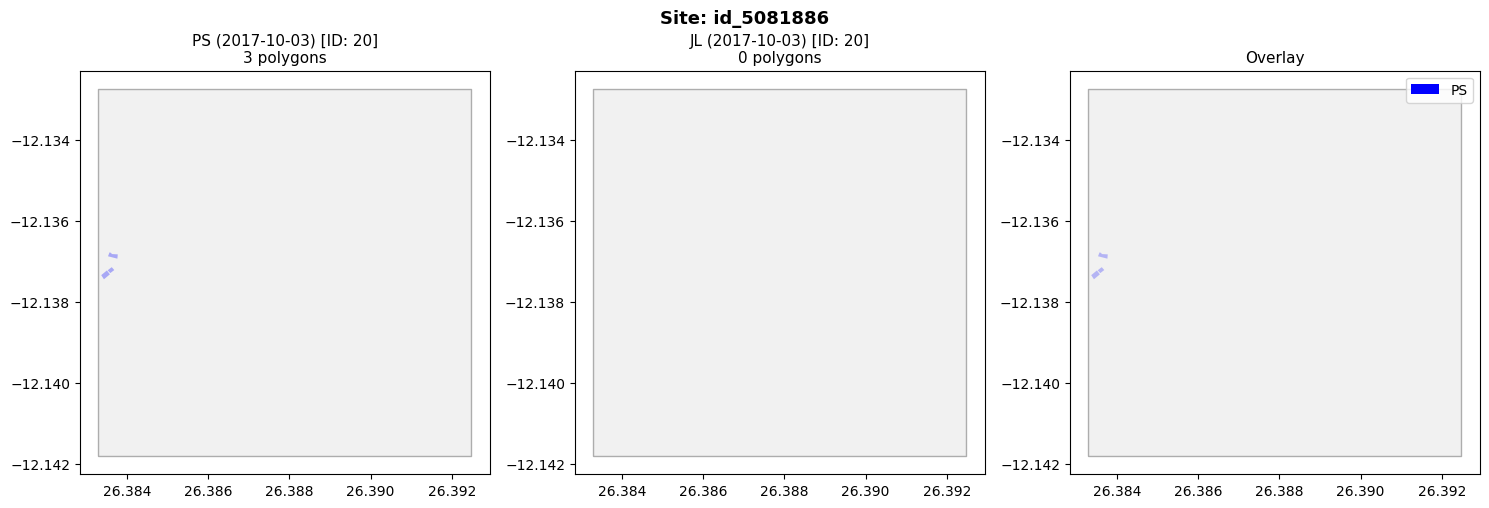

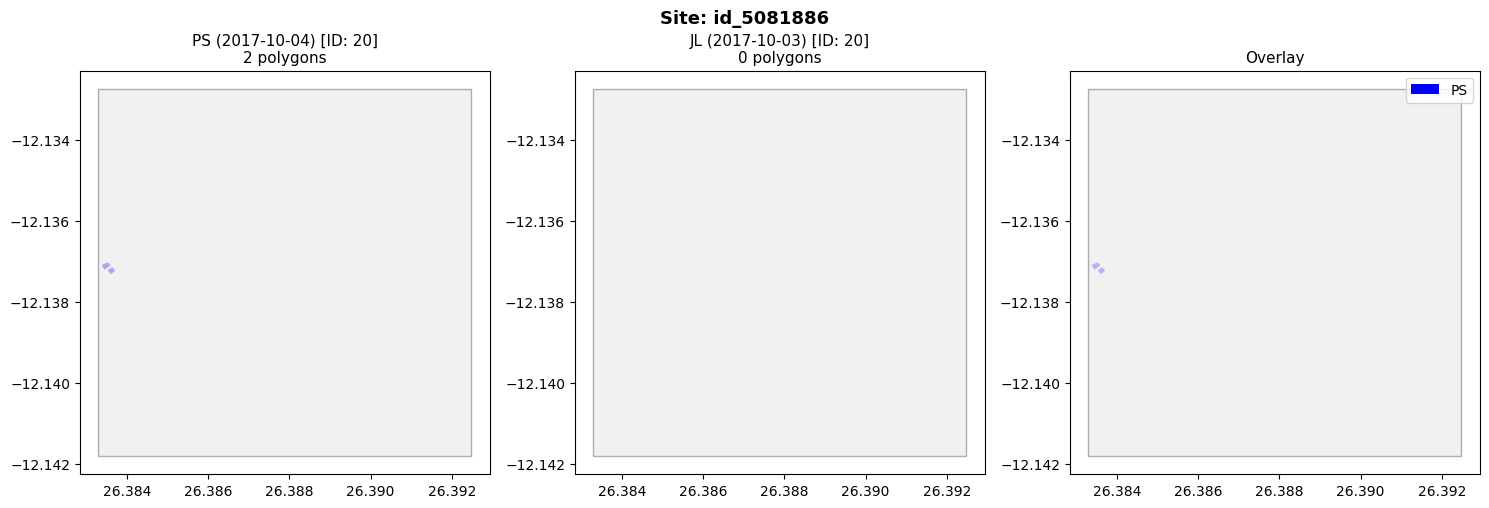

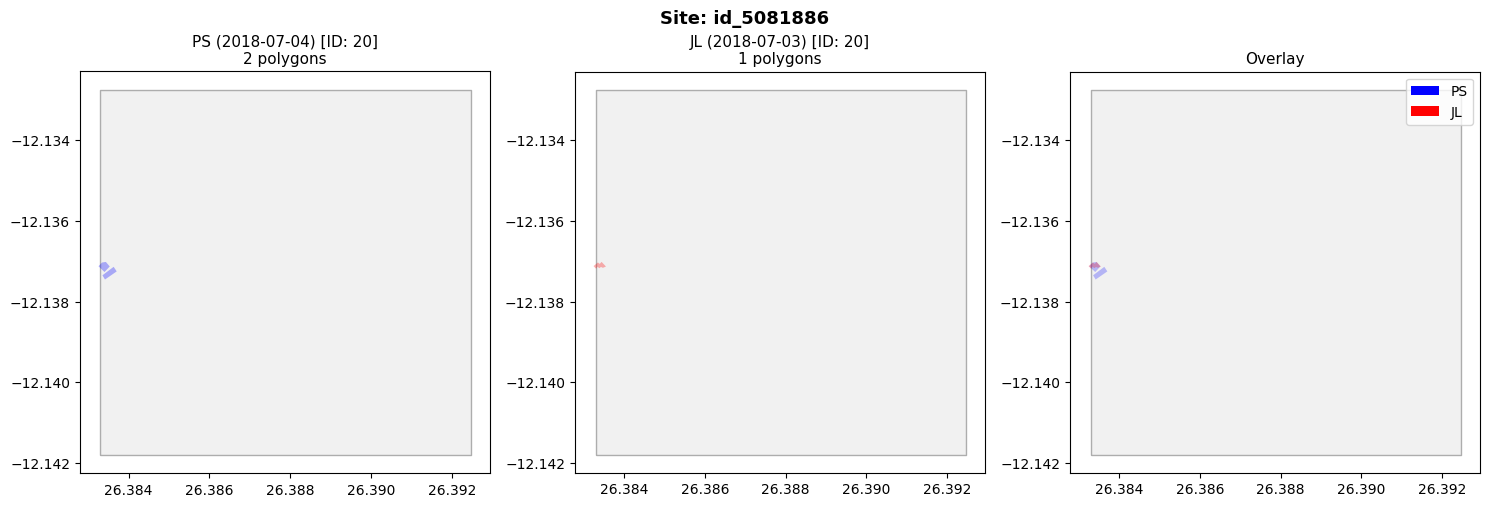

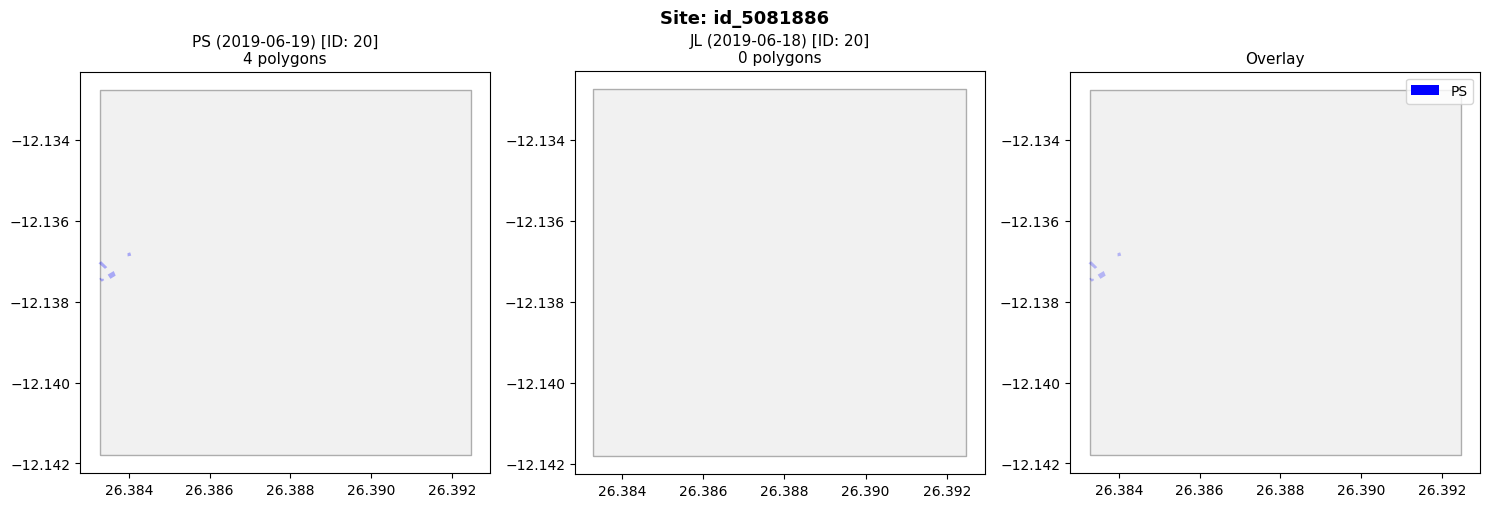

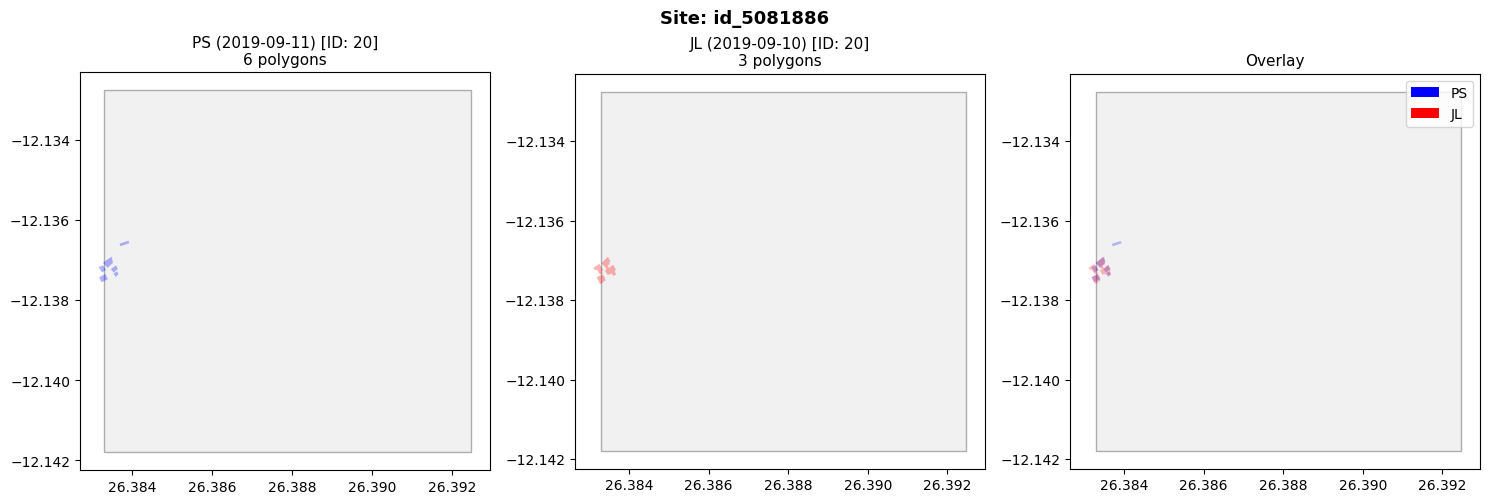

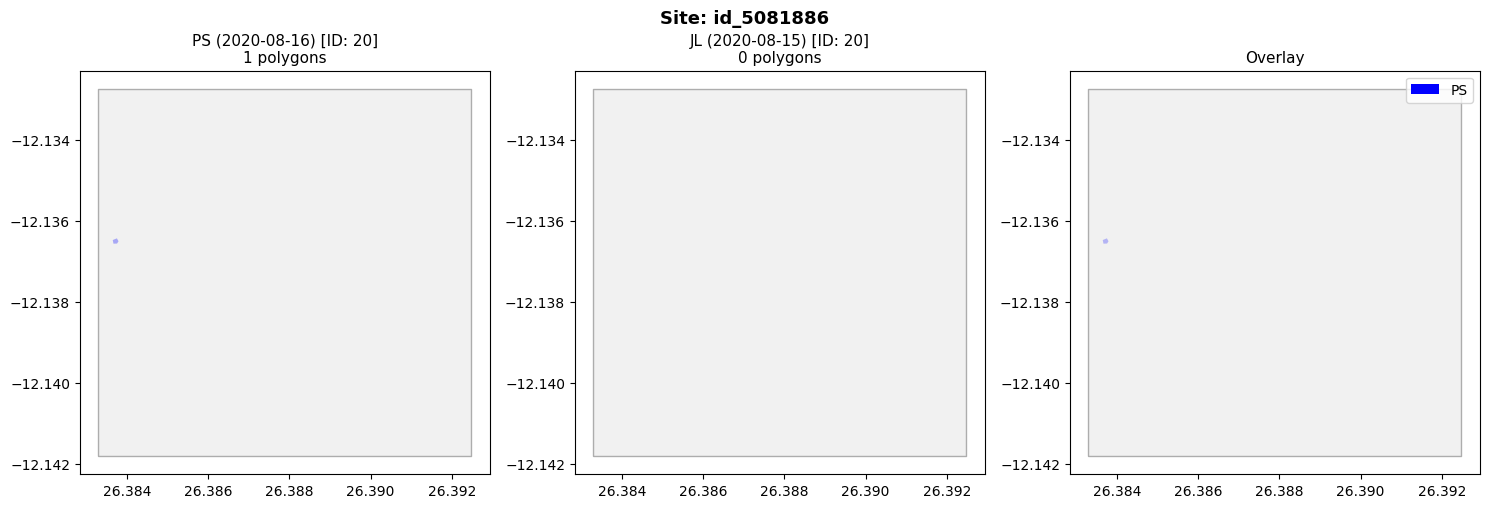

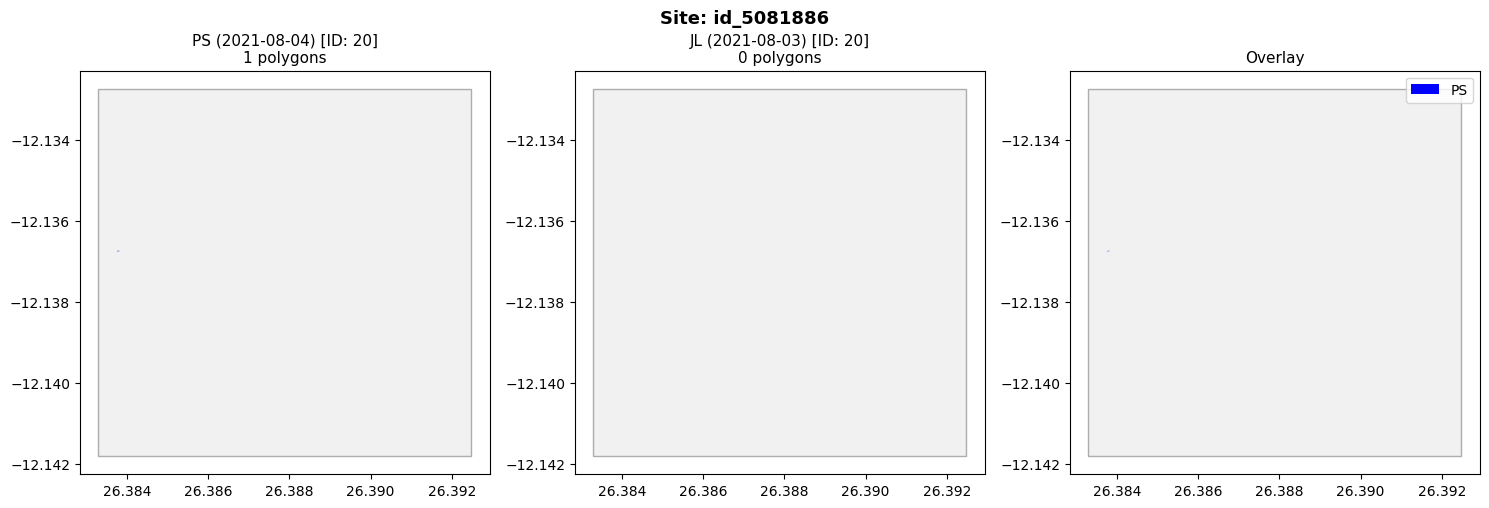

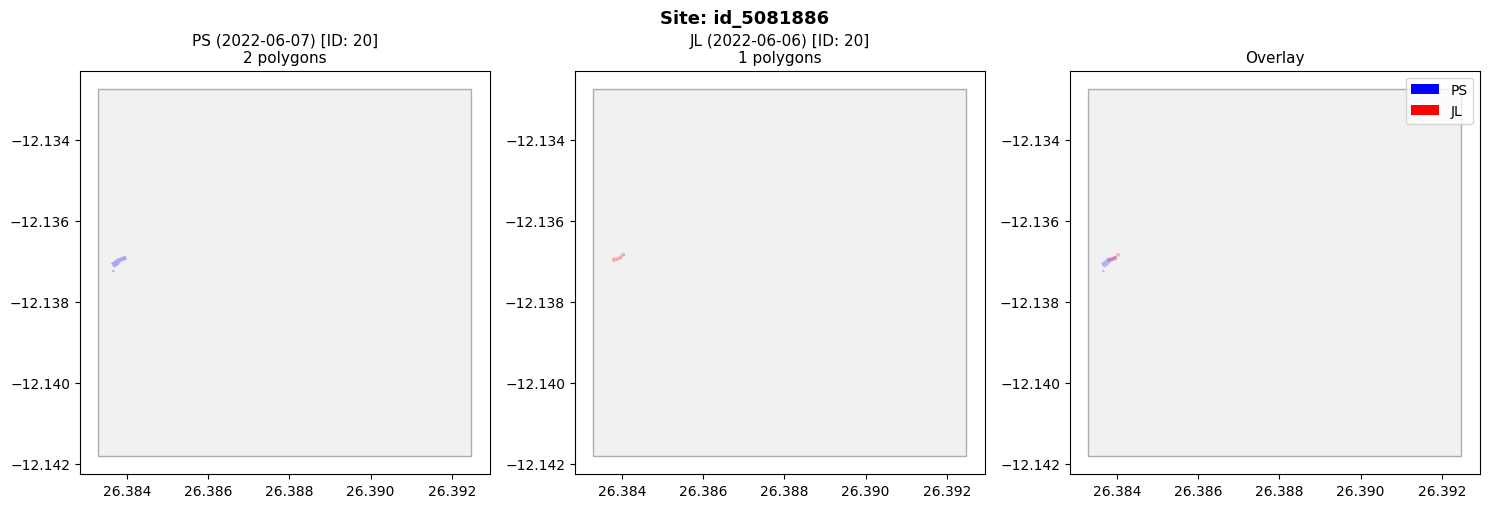

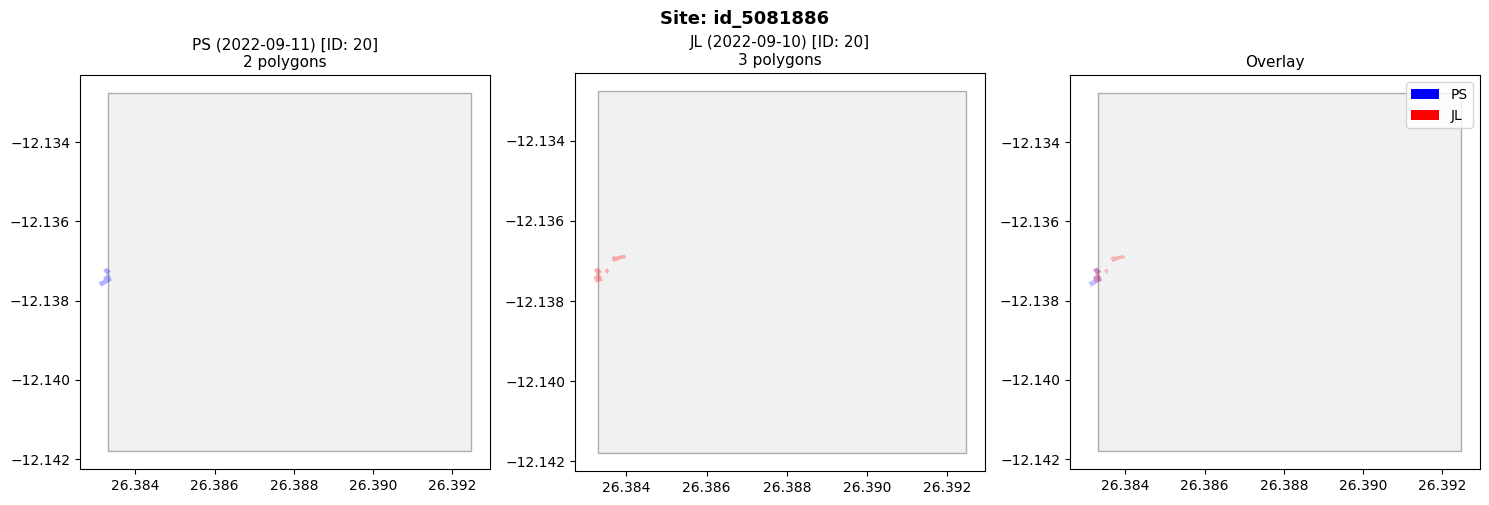

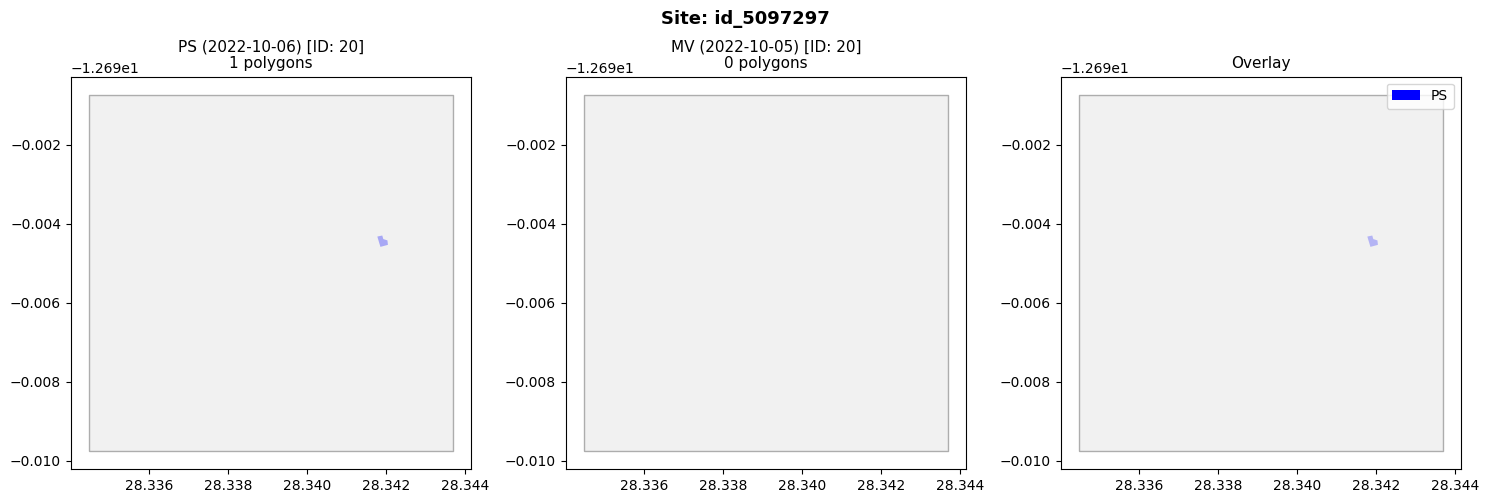

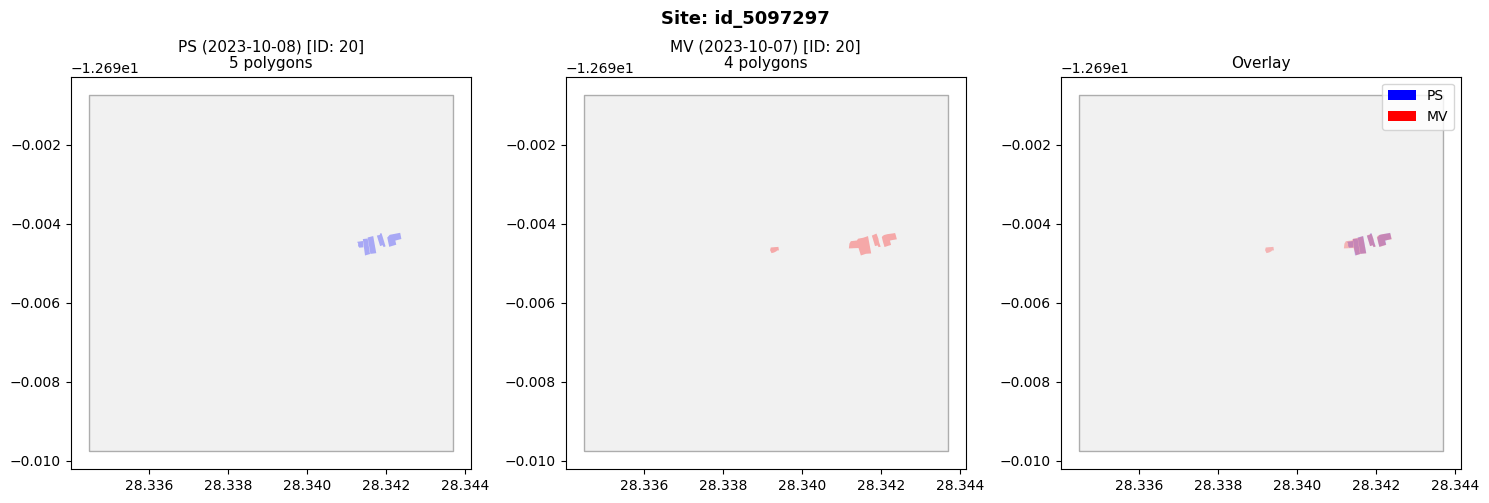

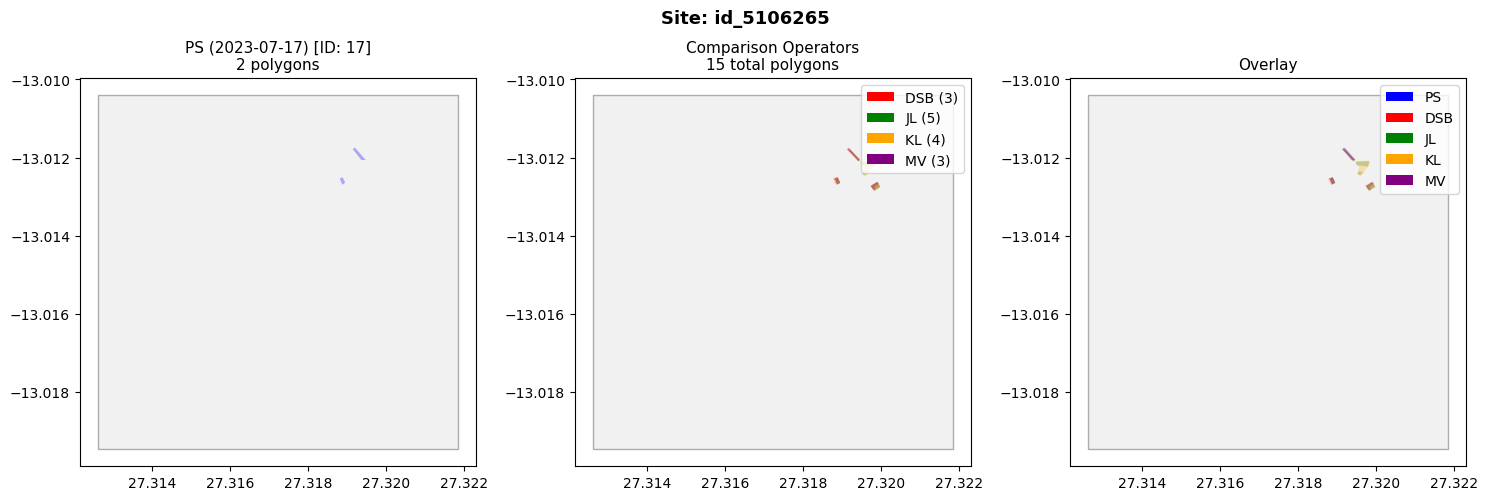

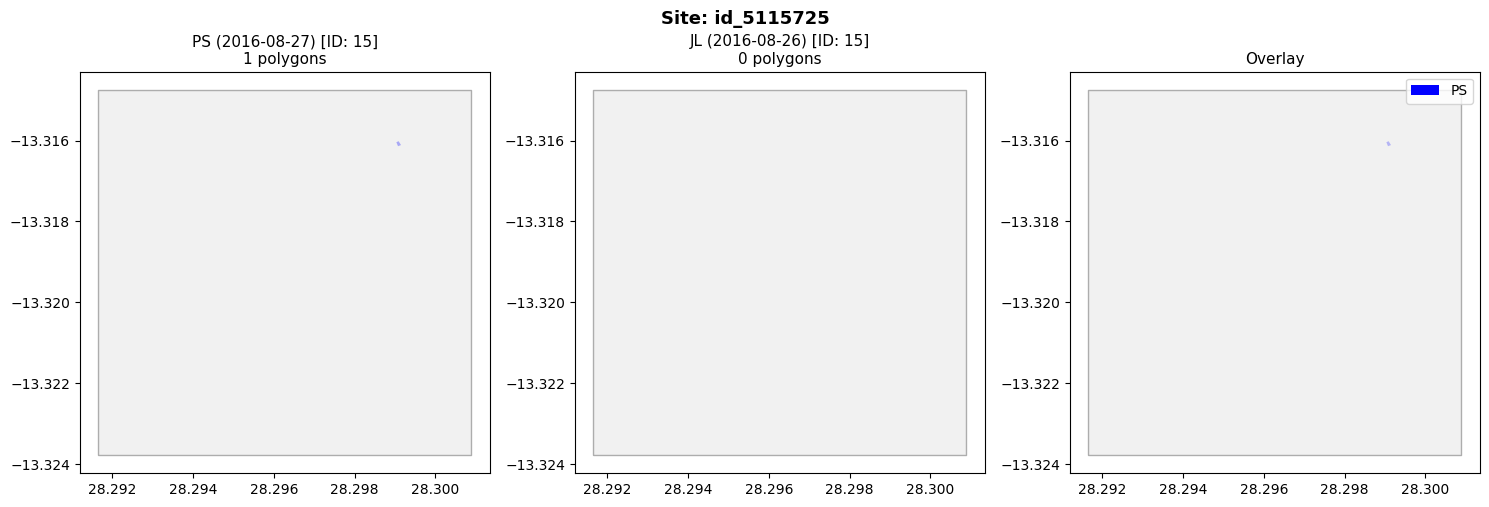

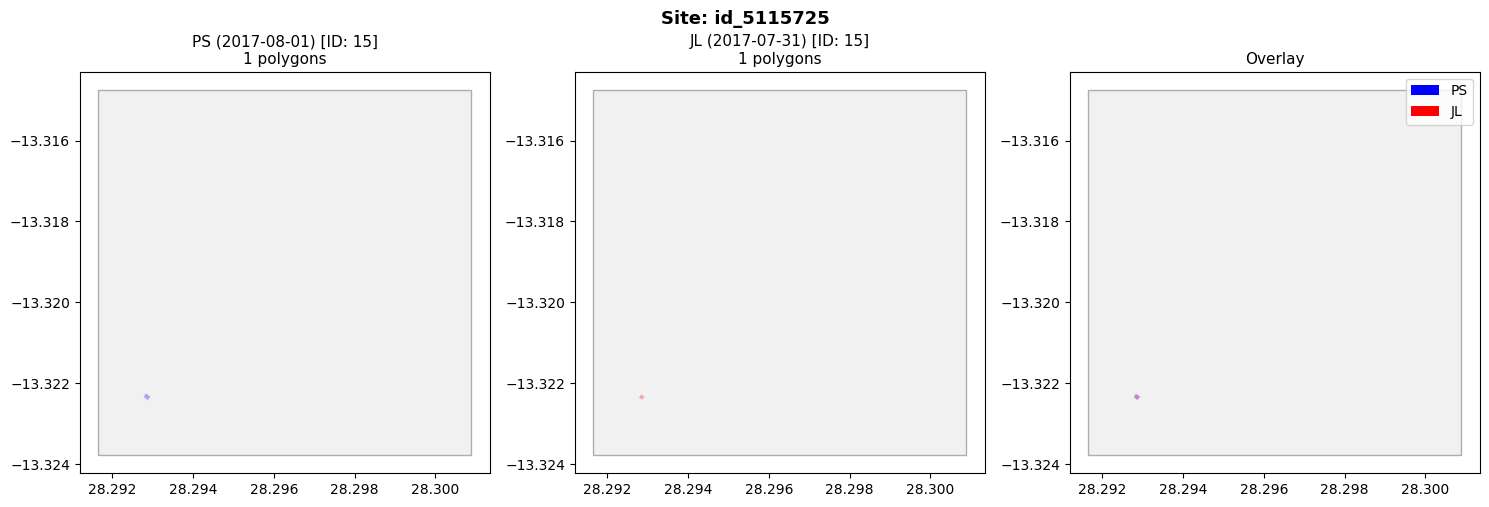

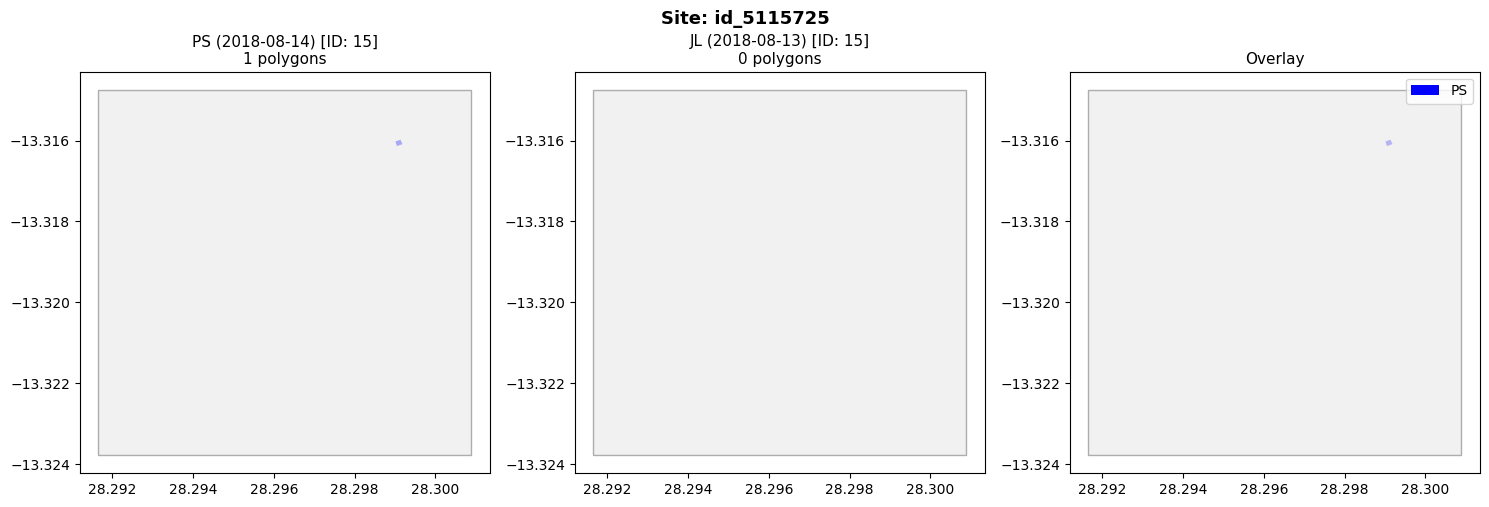

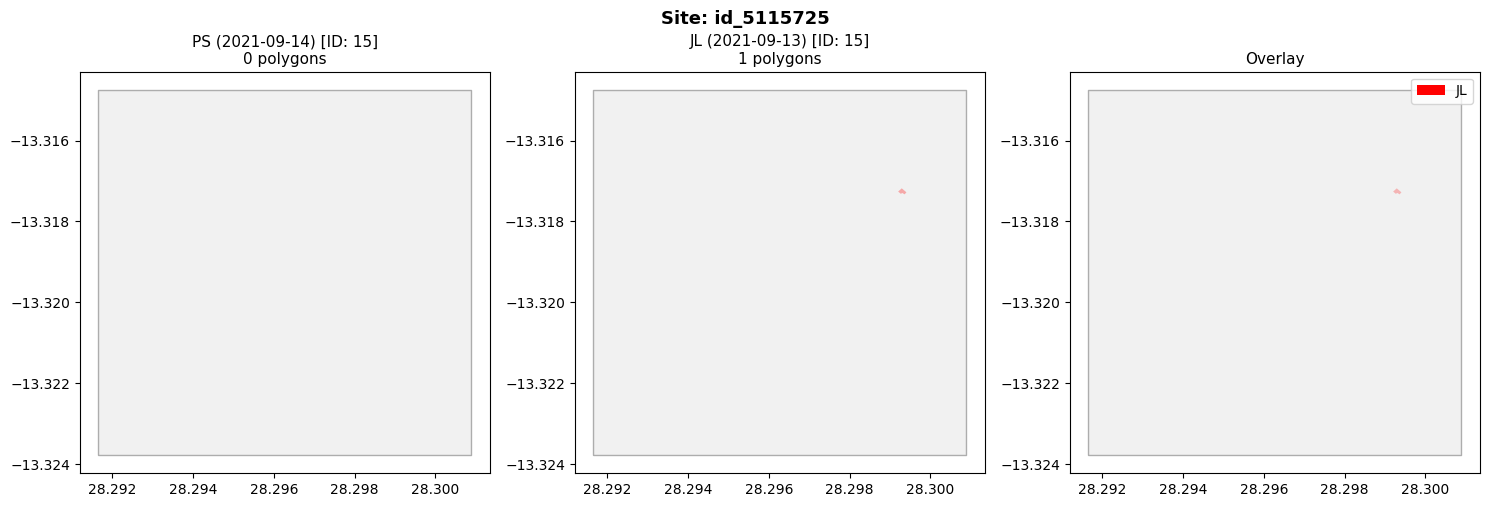

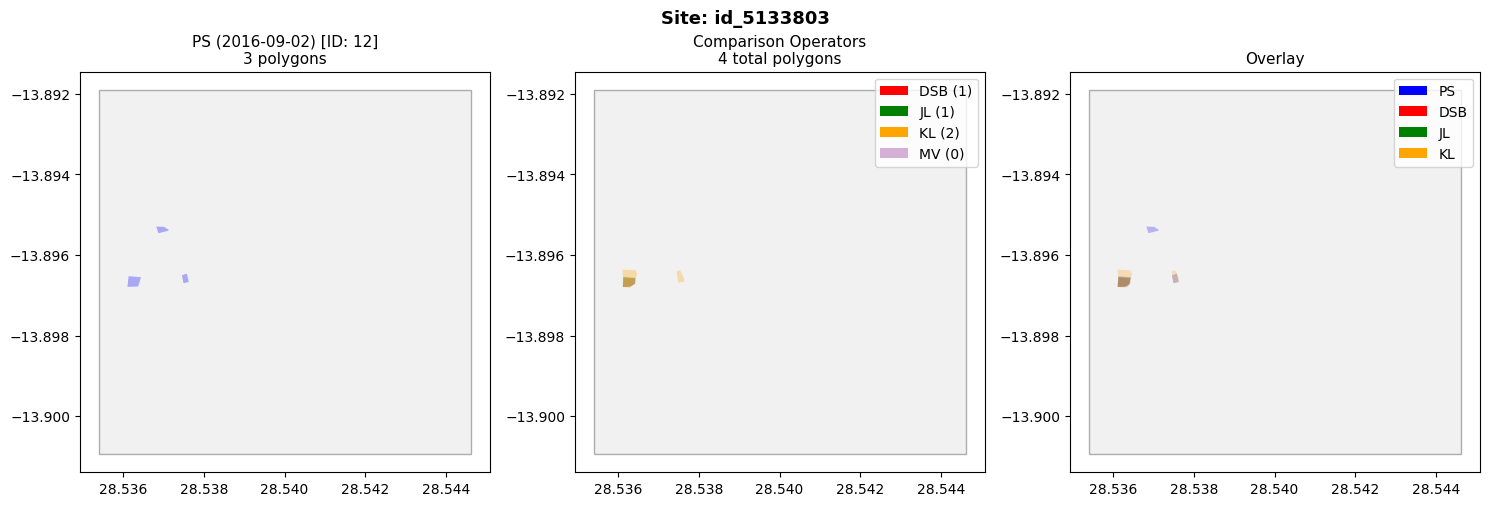

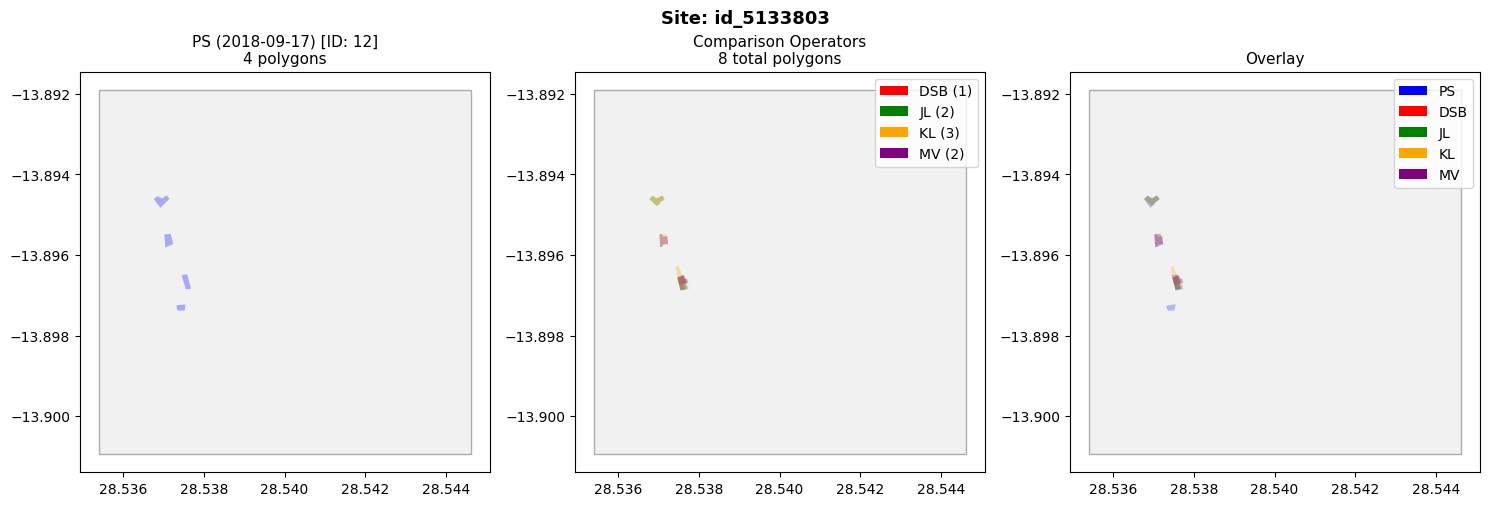

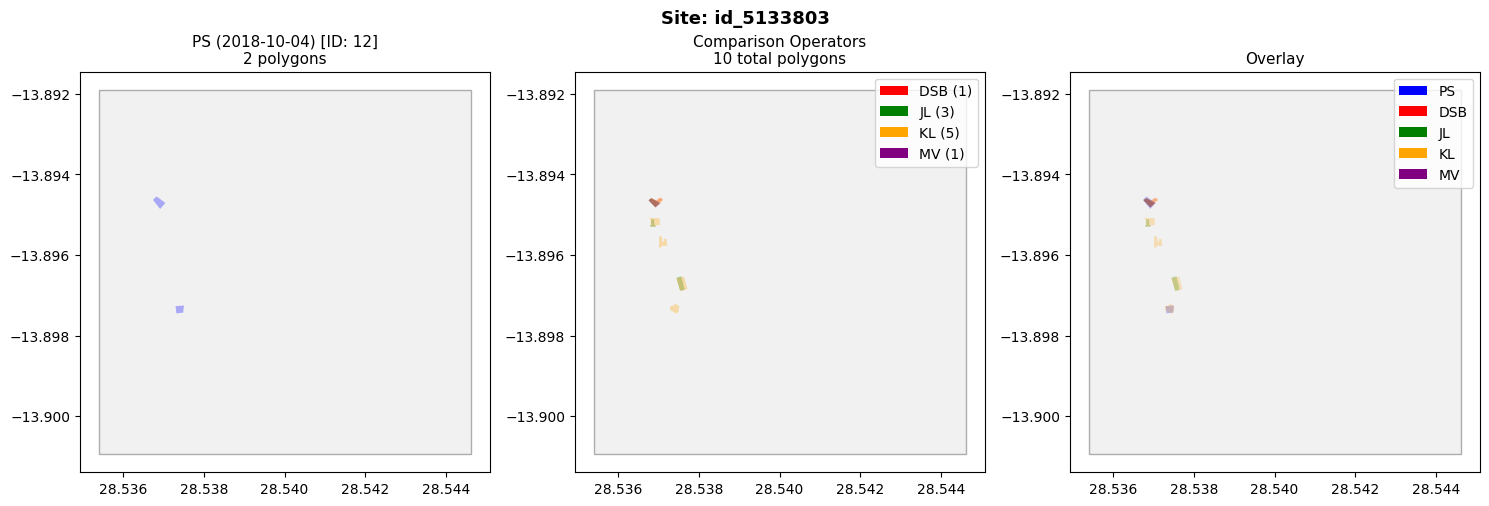

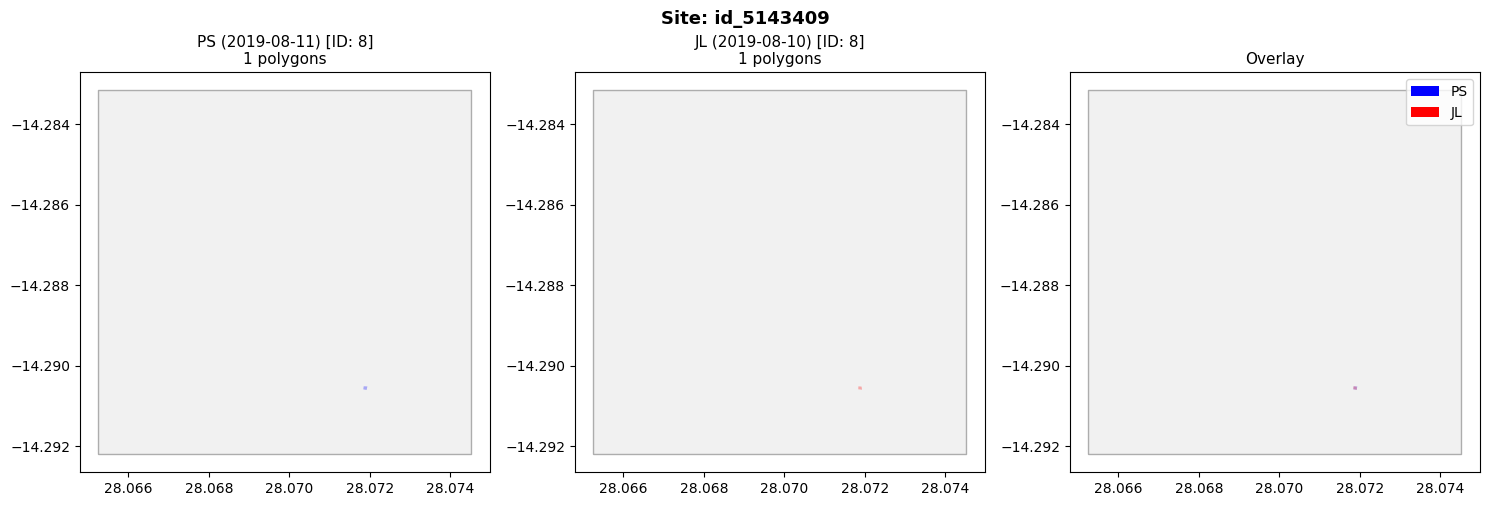

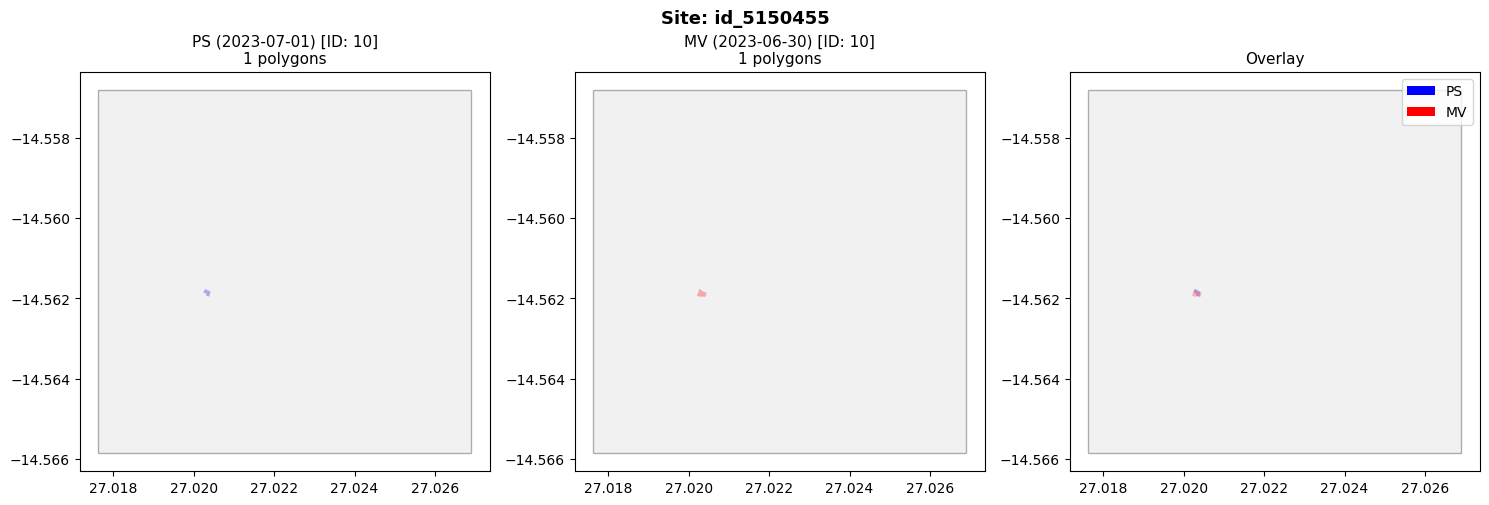

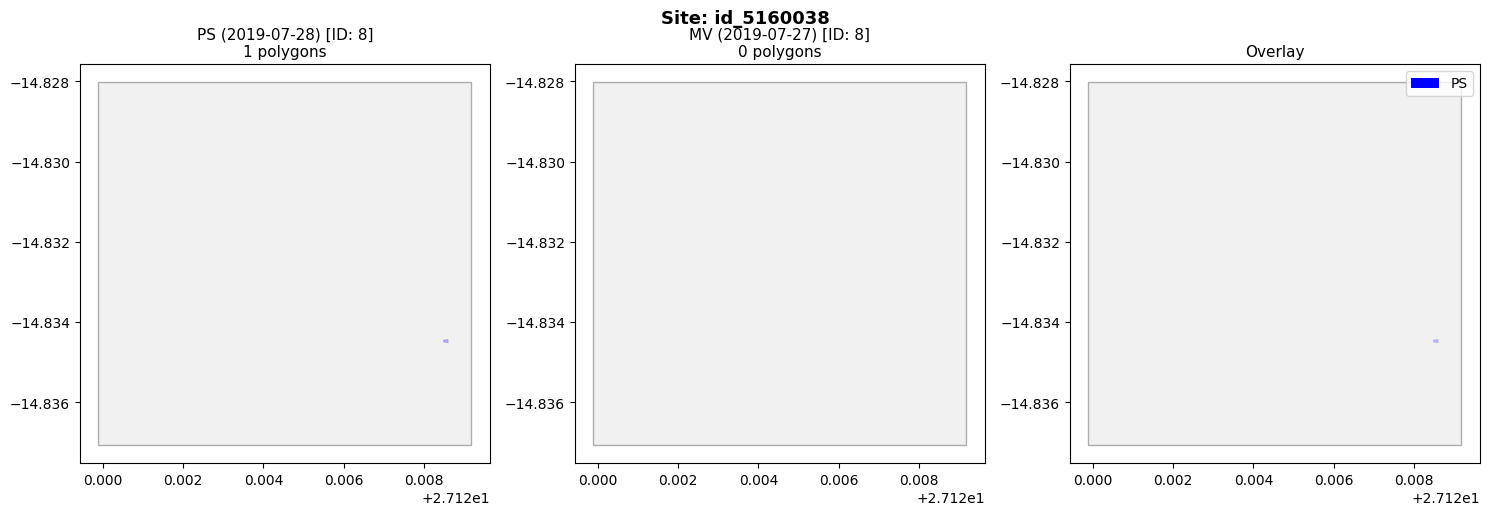

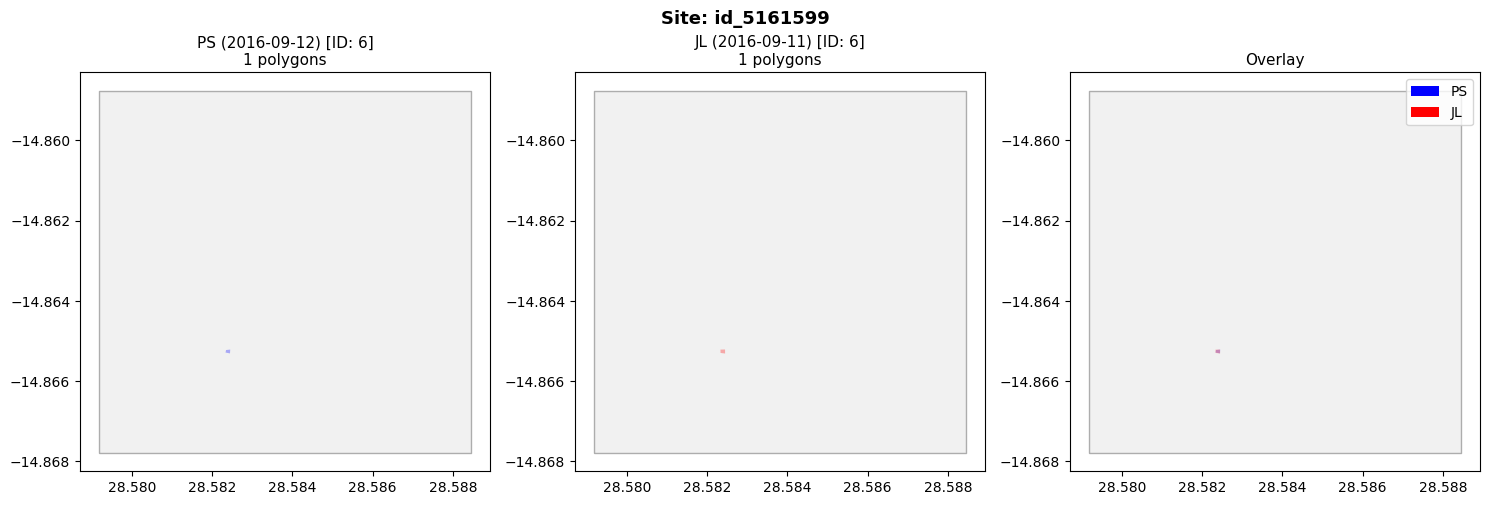

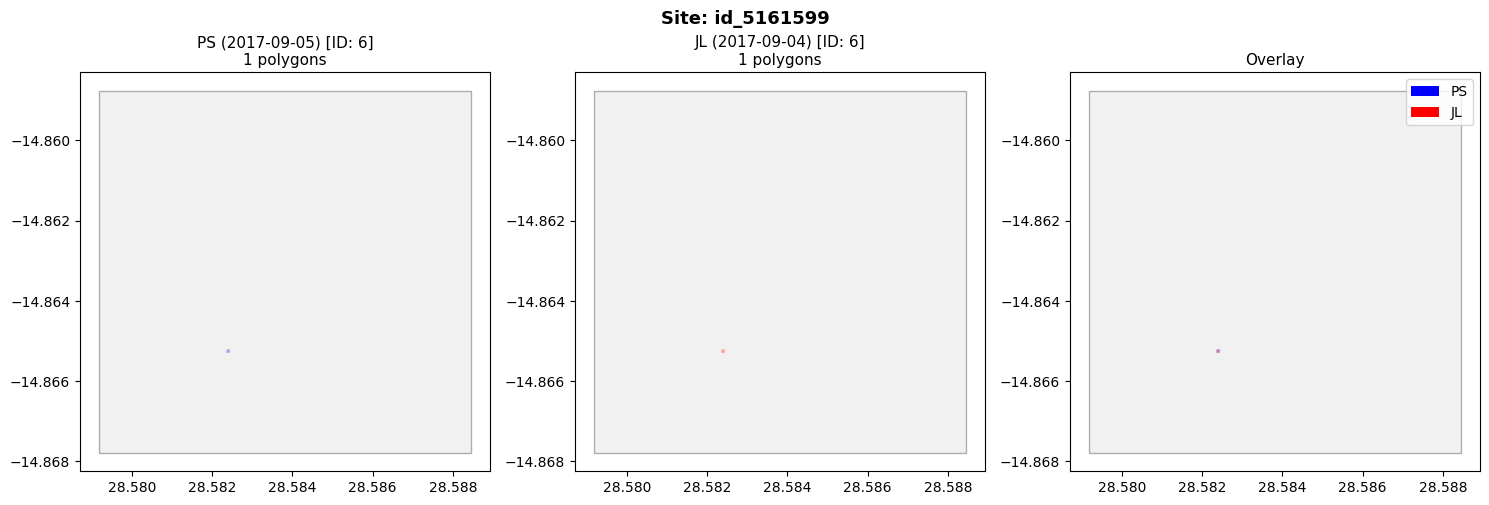

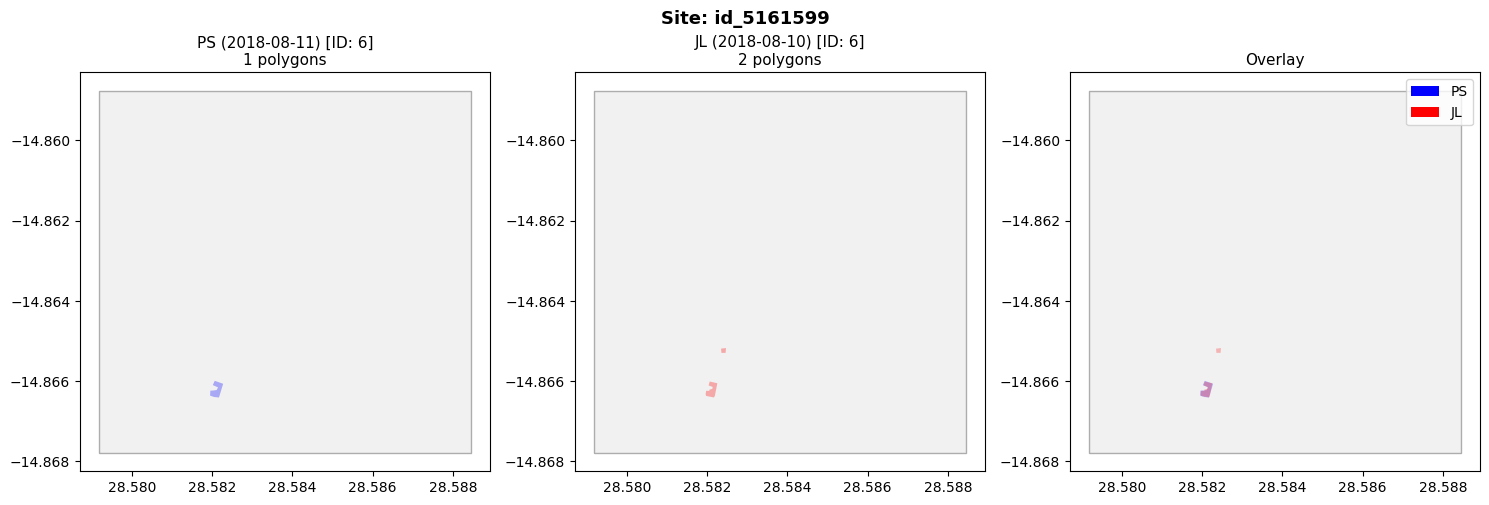

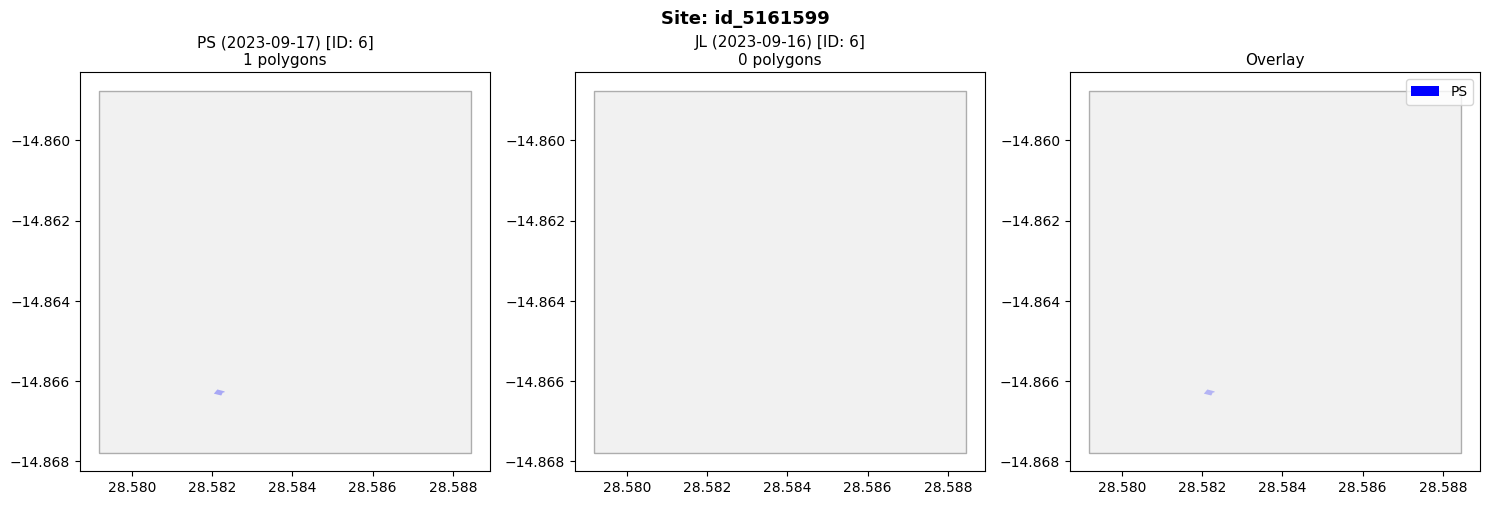

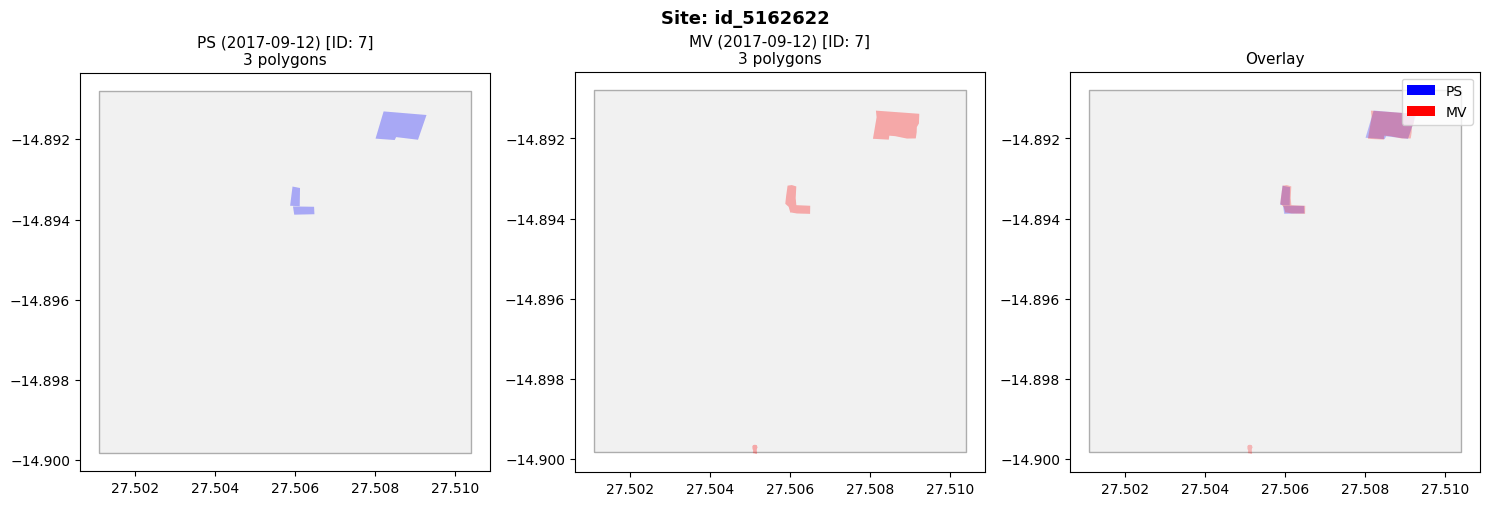

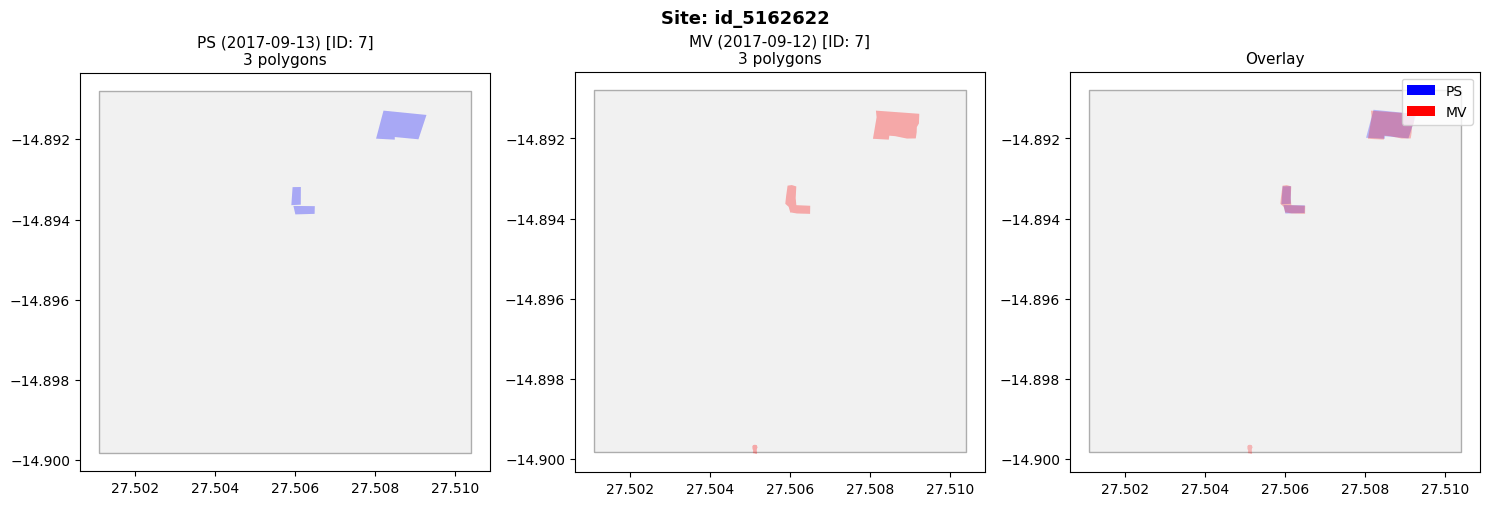

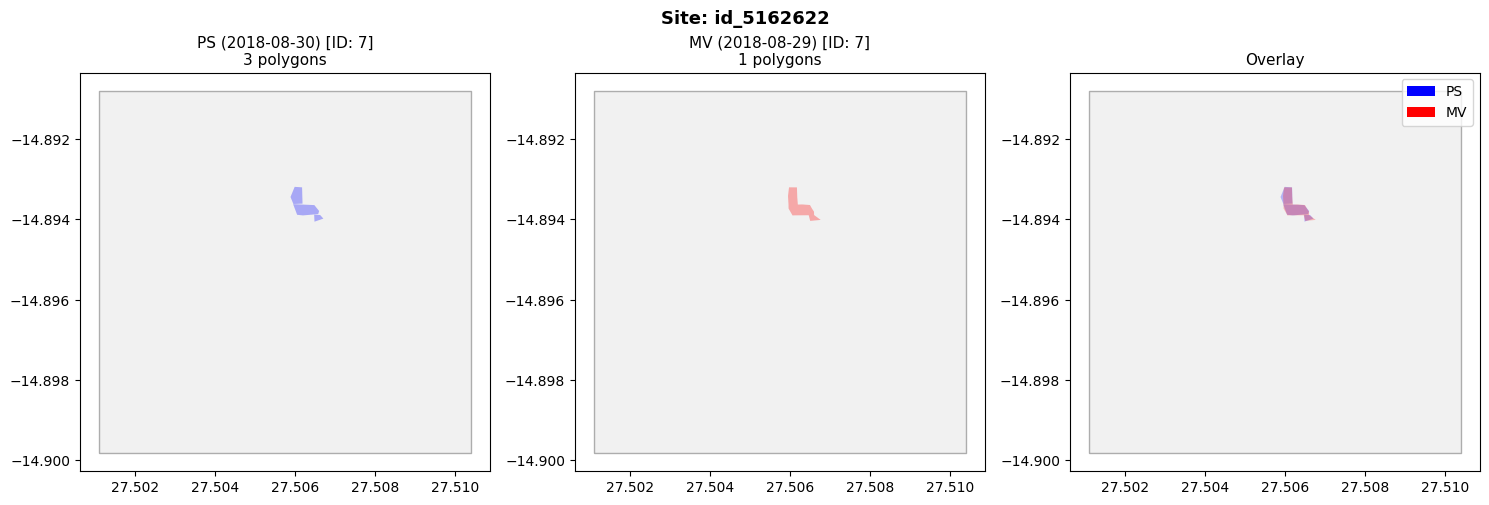

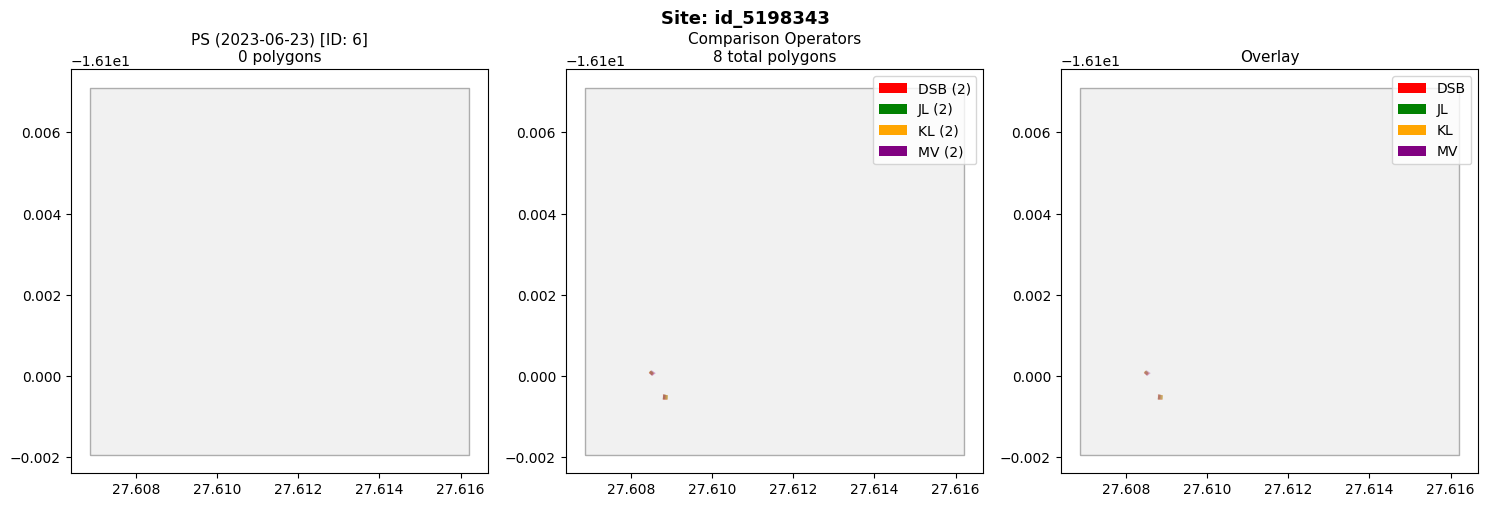

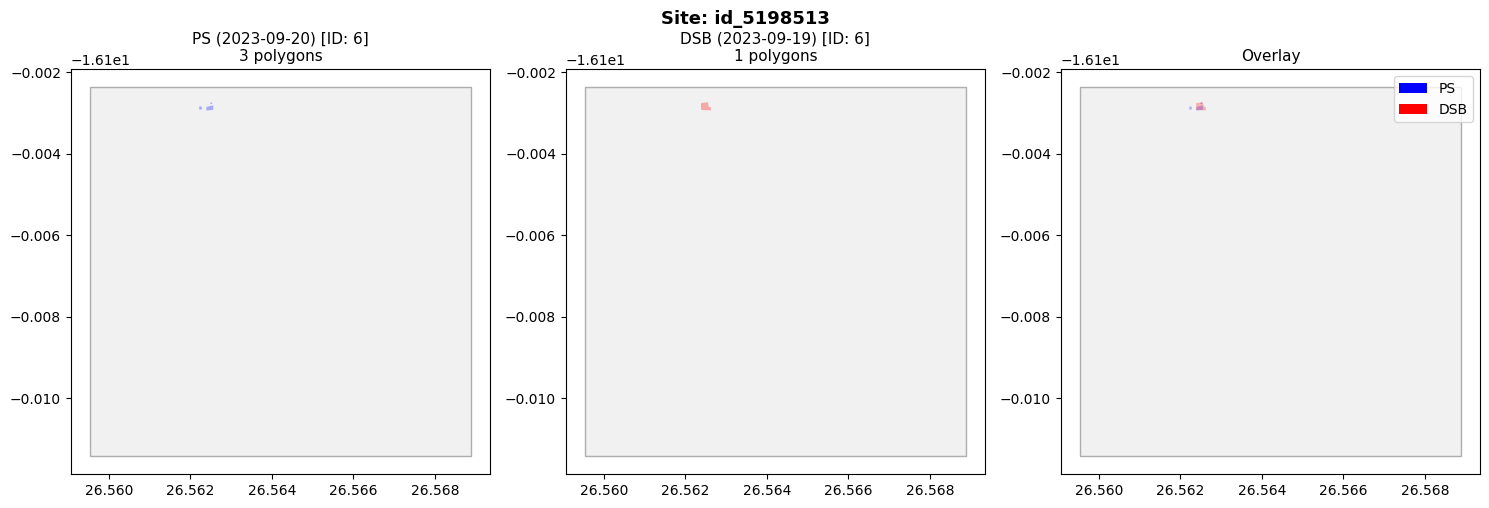

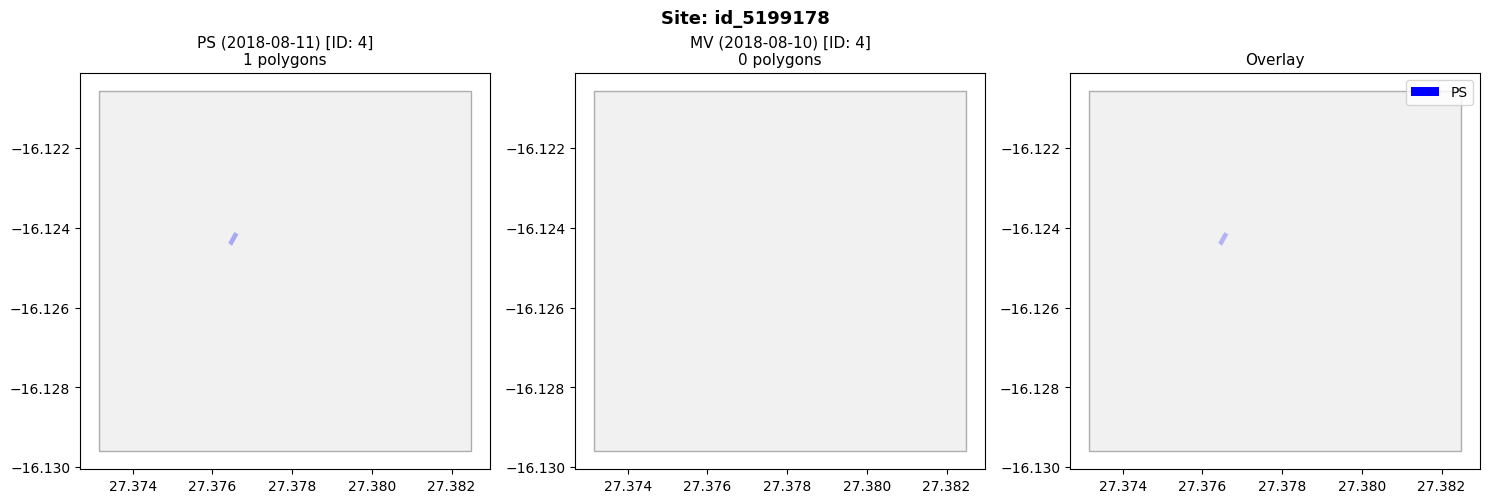

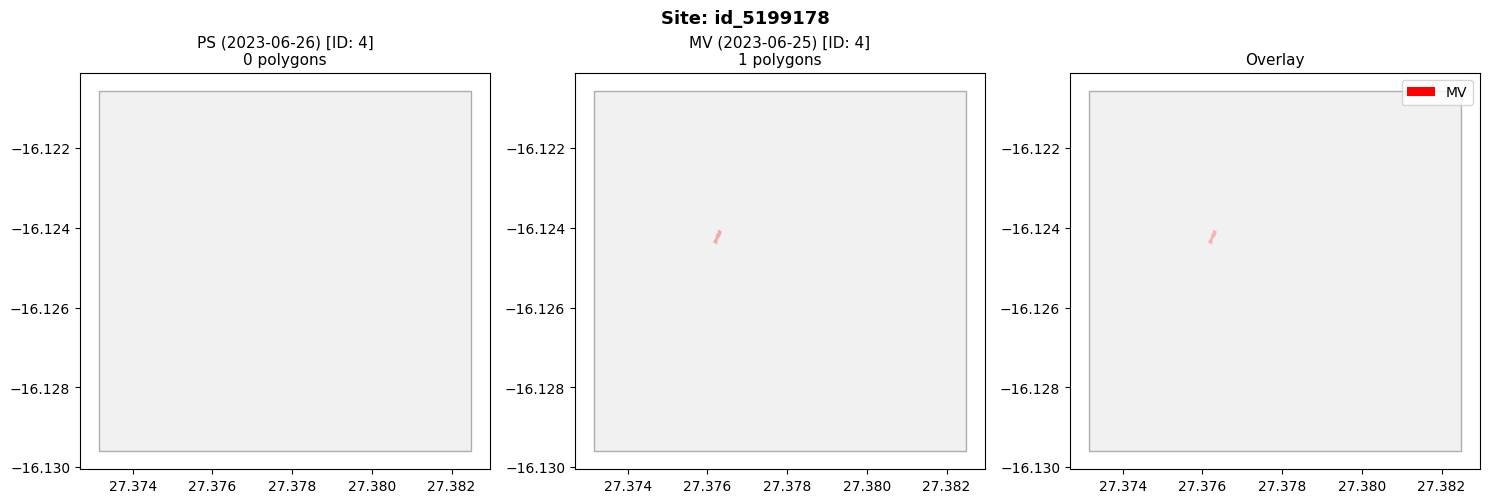

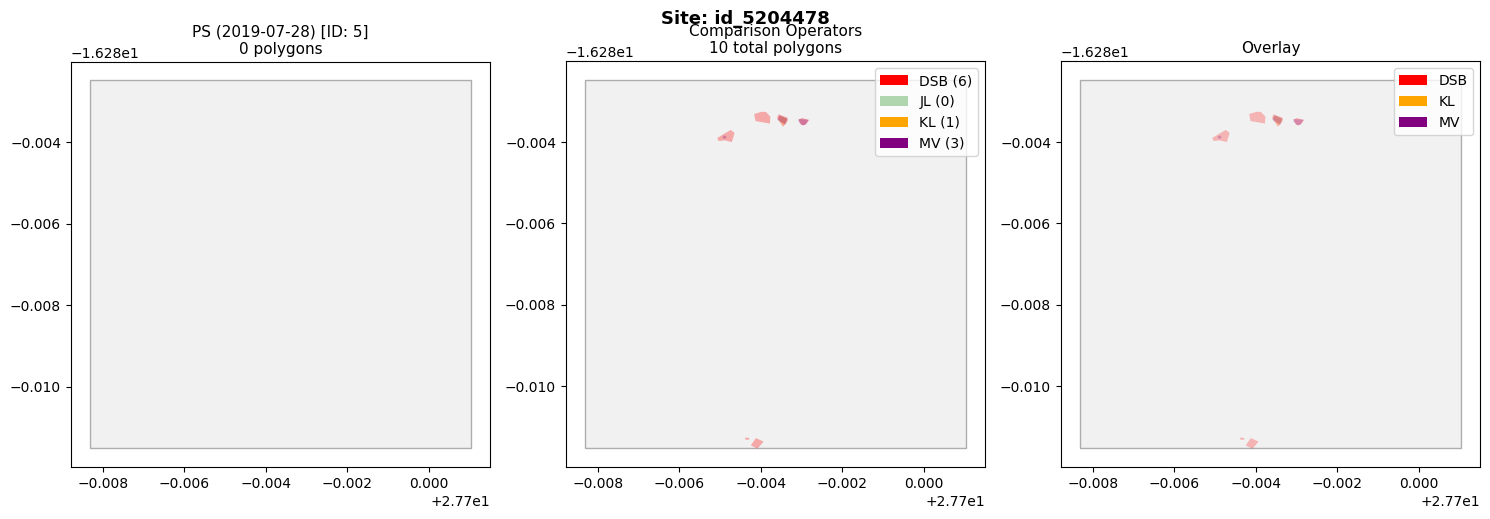

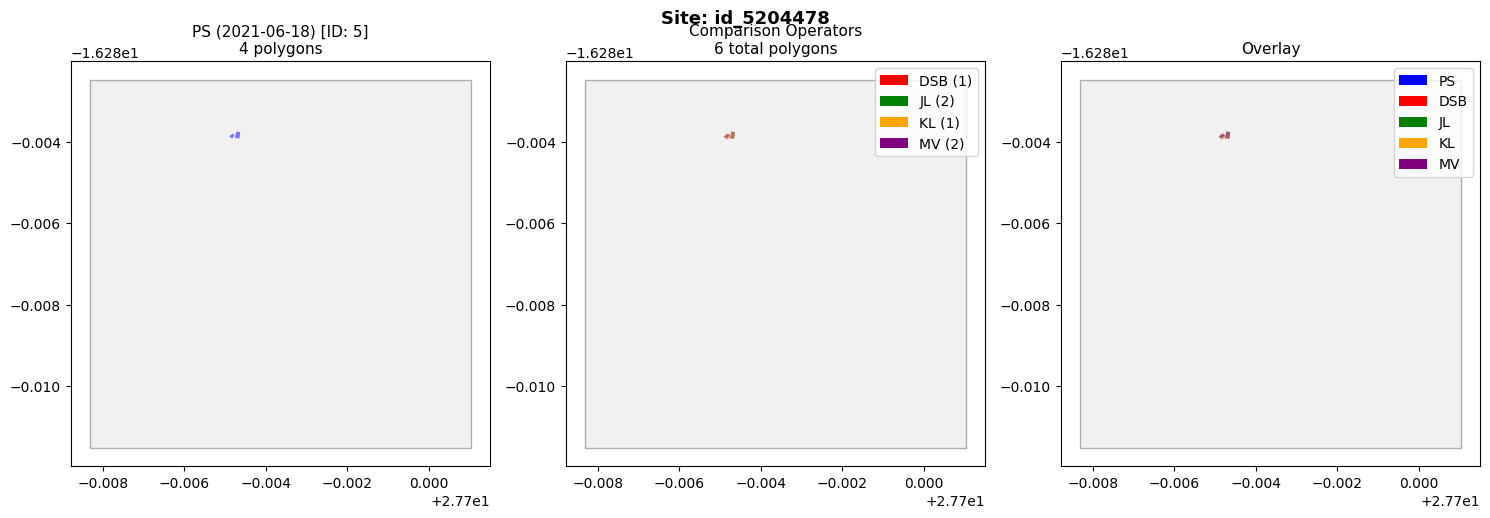

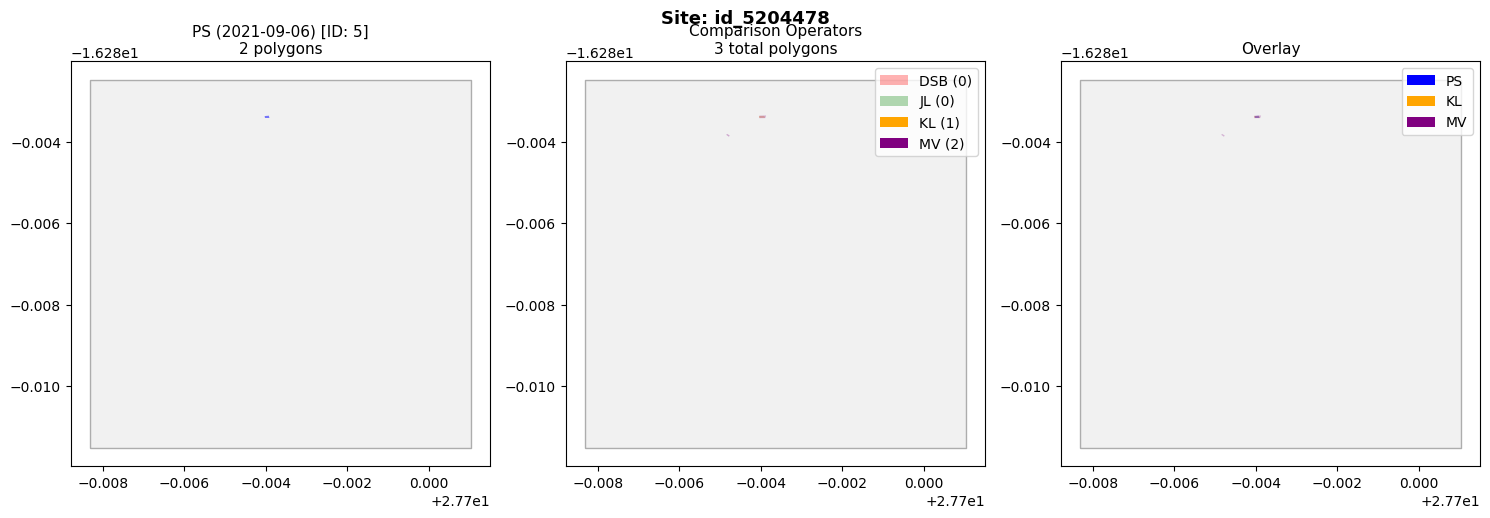

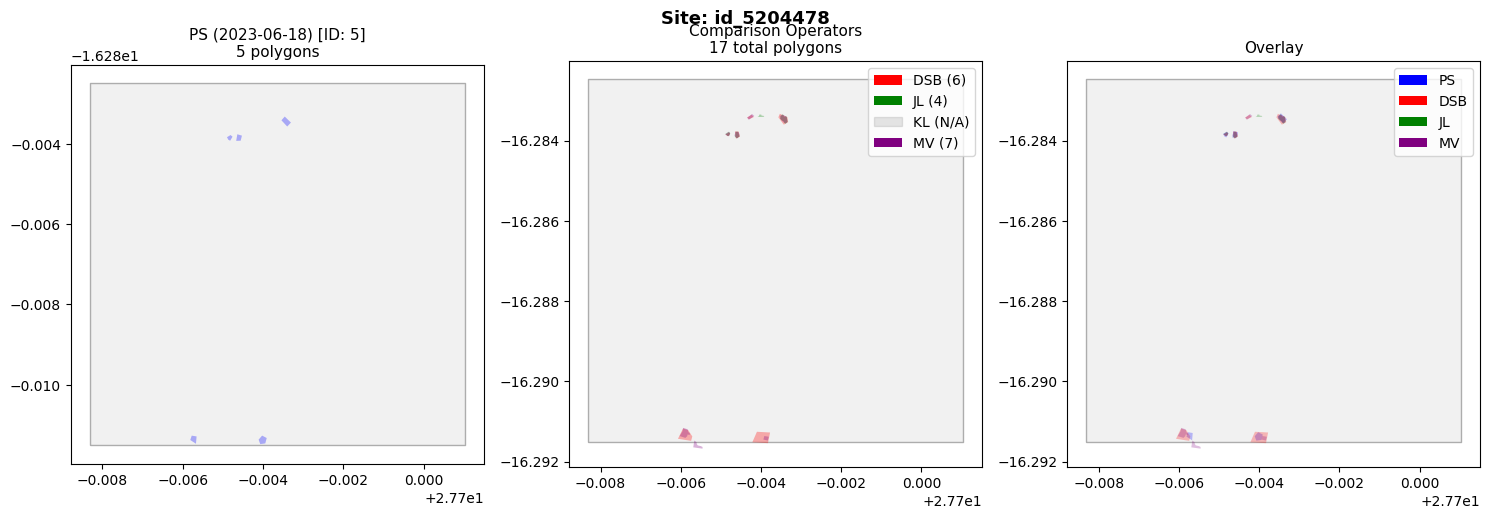

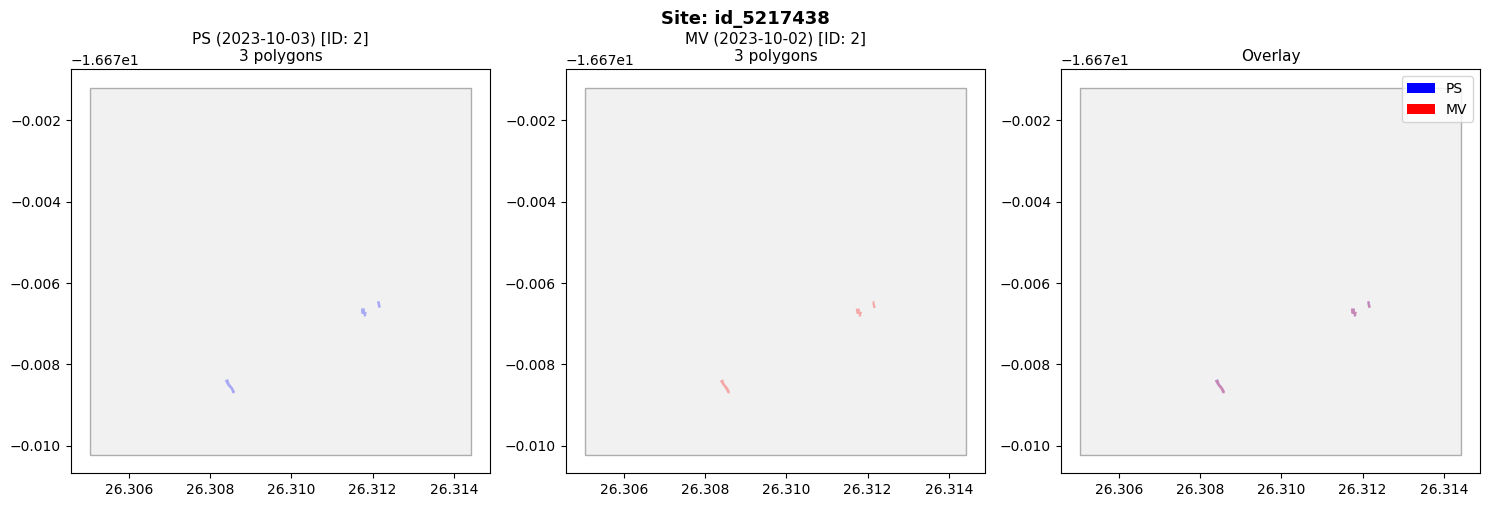

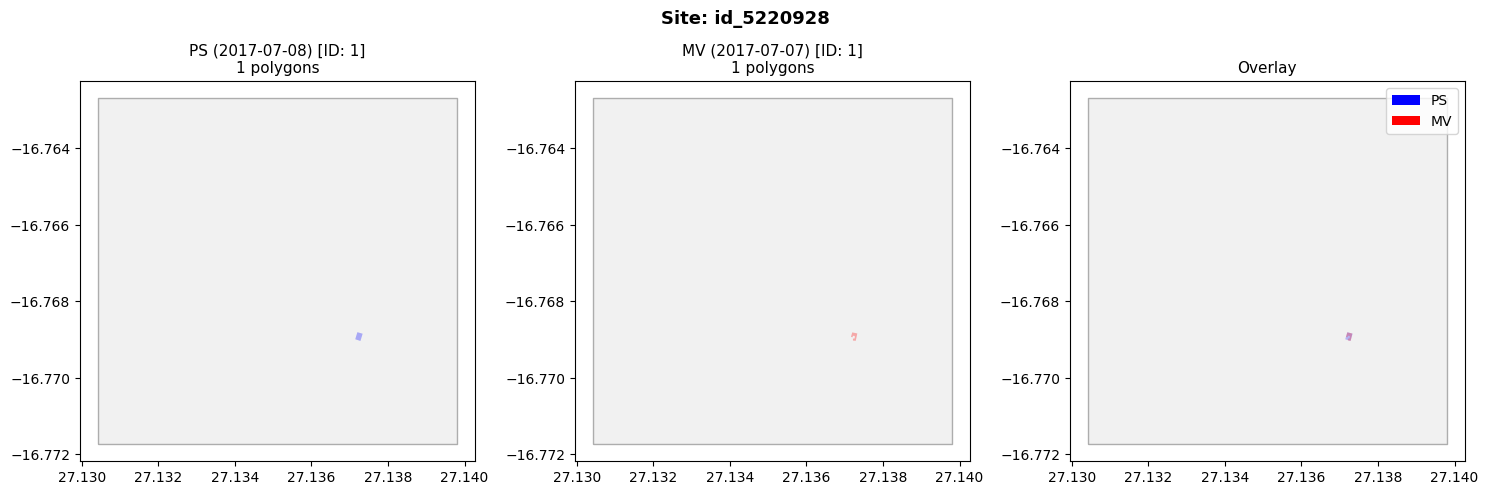

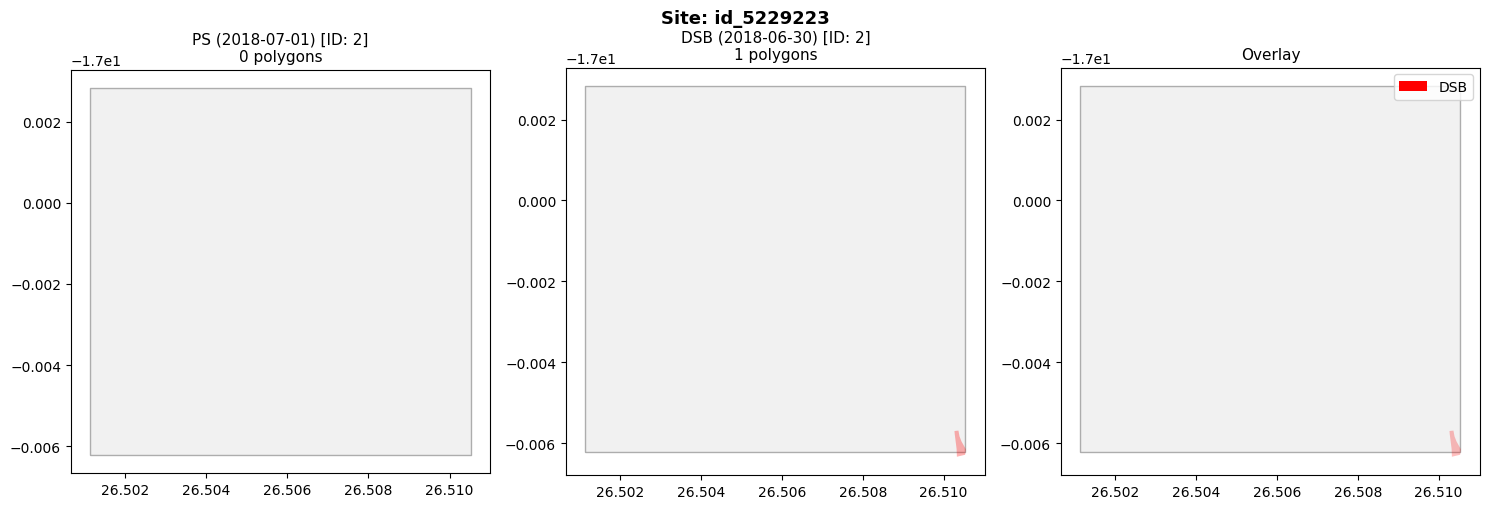

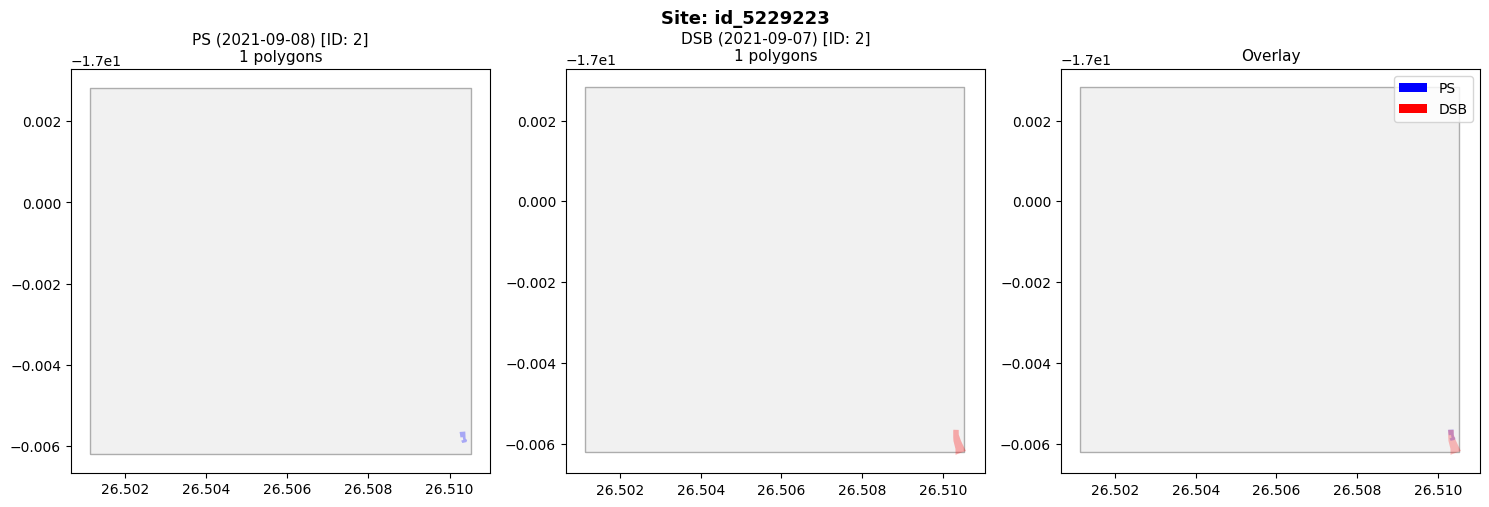

Saved 52 images to ../outputs/ps_comparisons_cert_3


In [18]:
# Plot only images where at least one labeler drew polygons
# Since output_dir is set, figures are automatically saved
print(f"\nPlotting images with polygons...")
print(f"Images will be saved to: {comparison.output_dir}")
comparison.plot_images_with_polygons()

# To plot ALL matched images (including those with no polygons):
# comparison.plot_all_images()

In [19]:
# Print summary statistics for each comparison operator
for op in comparison.comparison_operators:
    comparison.print_summary(op)


PS vs DSB Summary

Matched images: 86

Image-Level Detection:
  TP (both saw irrigation): 11
  FP (GT no irr, DSB saw irr): 4
  FN (GT saw irr, DSB no irr): 1
  TN (both saw no irrigation): 70
  Precision: 0.733
  Recall: 0.917
  F1: 0.815

Area Overlap (overall):
  Precision: 0.341
  Recall: 0.527
  F1: 0.414
  IoU: 0.261

PS vs JL Summary

Matched images: 100

Image-Level Detection:
  TP (both saw irrigation): 17
  FP (GT no irr, JL saw irr): 4
  FN (GT saw irr, JL no irr): 11
  TN (both saw no irrigation): 68
  Precision: 0.810
  Recall: 0.607
  F1: 0.694

Area Overlap (overall):
  Precision: 0.467
  Recall: 0.408
  F1: 0.436
  IoU: 0.278

PS vs KL Summary

Matched images: 47

Image-Level Detection:
  TP (both saw irrigation): 8
  FP (GT no irr, KL saw irr): 3
  FN (GT saw irr, KL no irr): 0
  TN (both saw no irrigation): 36
  Precision: 0.727
  Recall: 1.000
  F1: 0.842

Area Overlap (overall):
  Precision: 0.376
  Recall: 0.756
  F1: 0.502
  IoU: 0.335

PS vs MV Summary

Matched 

## Summary Tables

Generate summary tables with metrics compiled across all labelers, with weighted averages based on total images labeled.

In [20]:
# Generate and save summary tables
detection_table, area_table = comparison.generate_summary_tables()


IMAGE-LEVEL DETECTION METRICS
    Operator  Matched Images  Total Images Labeled  TP  FP  FN  TN  Precision   Recall       F1
         DSB              86                   588  11   4   1  70   0.733333 0.916667 0.814815
          JL             100                   582  17   4  11  68   0.809524 0.607143 0.693878
          KL              47                   681   8   3   0  36   0.727273 1.000000 0.842105
          MV              88                   623  14   7   5  62   0.666667 0.736842 0.700000
Weighted Avg             321                  2474  50  18  17 236   0.732801 0.821508 0.764964

AREA OVERLAP METRICS
    Operator  Total Images Labeled  Precision   Recall       F1      IoU
         DSB                   588   0.340657 0.527323 0.413918 0.260969
          JL                   582   0.467366 0.407905 0.435616 0.278458
          KL                   681   0.376206 0.755558 0.502305 0.335386
          MV                   623   0.786966 0.808115 0.797400 0.663064
Weight